/Users/shabeebameen/Projects/tvm-fire/toolbox/manuscriptPlots.py:55: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, self.ax = plt.subplots()


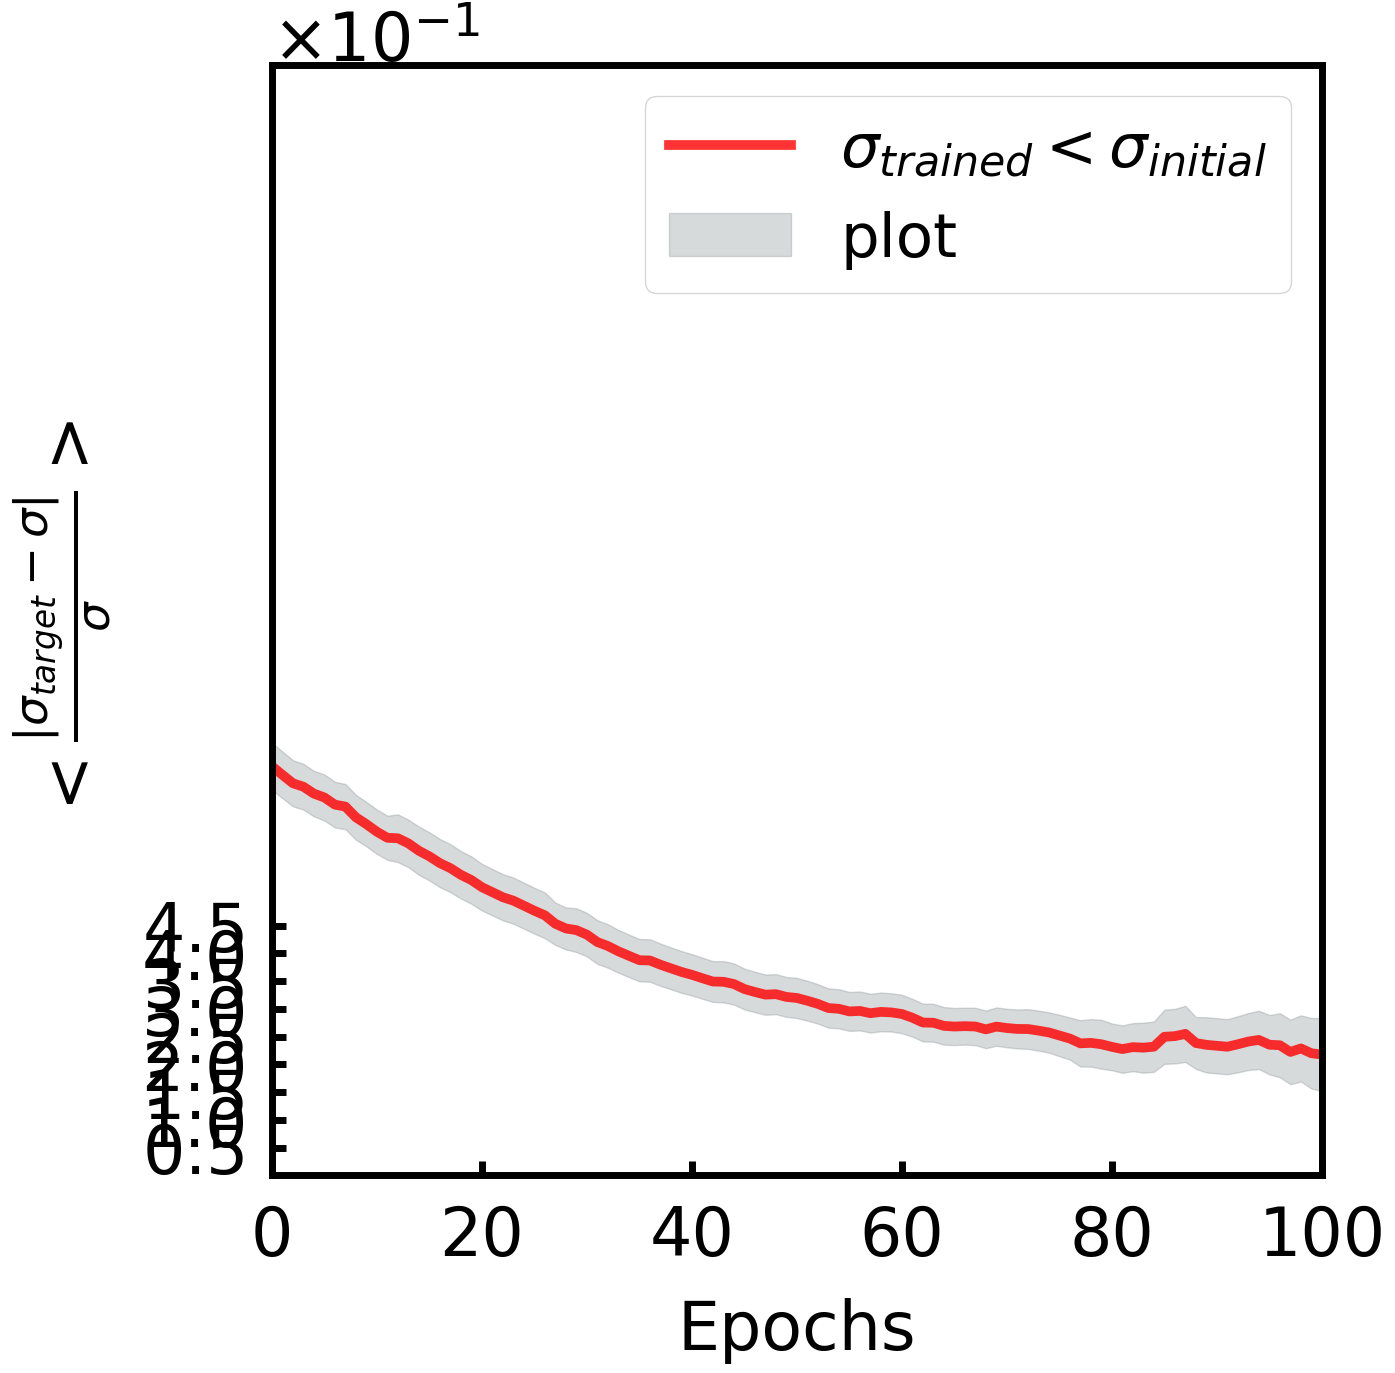

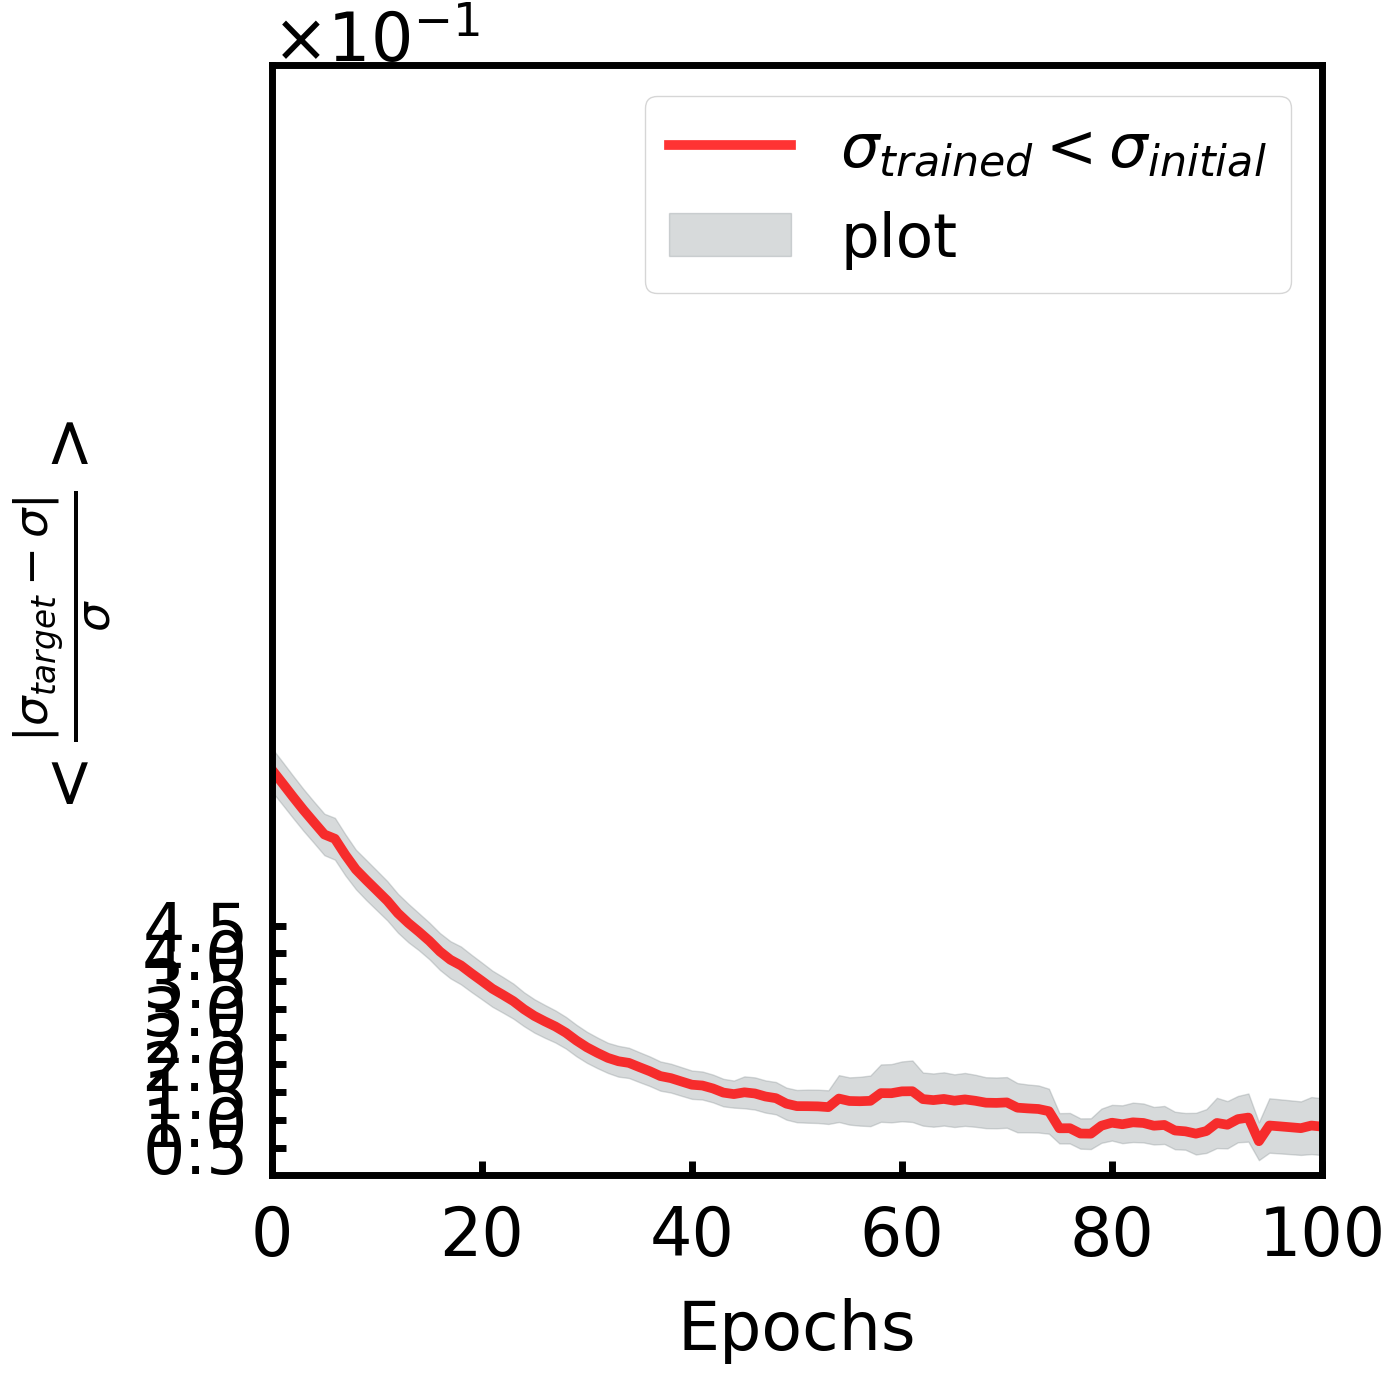

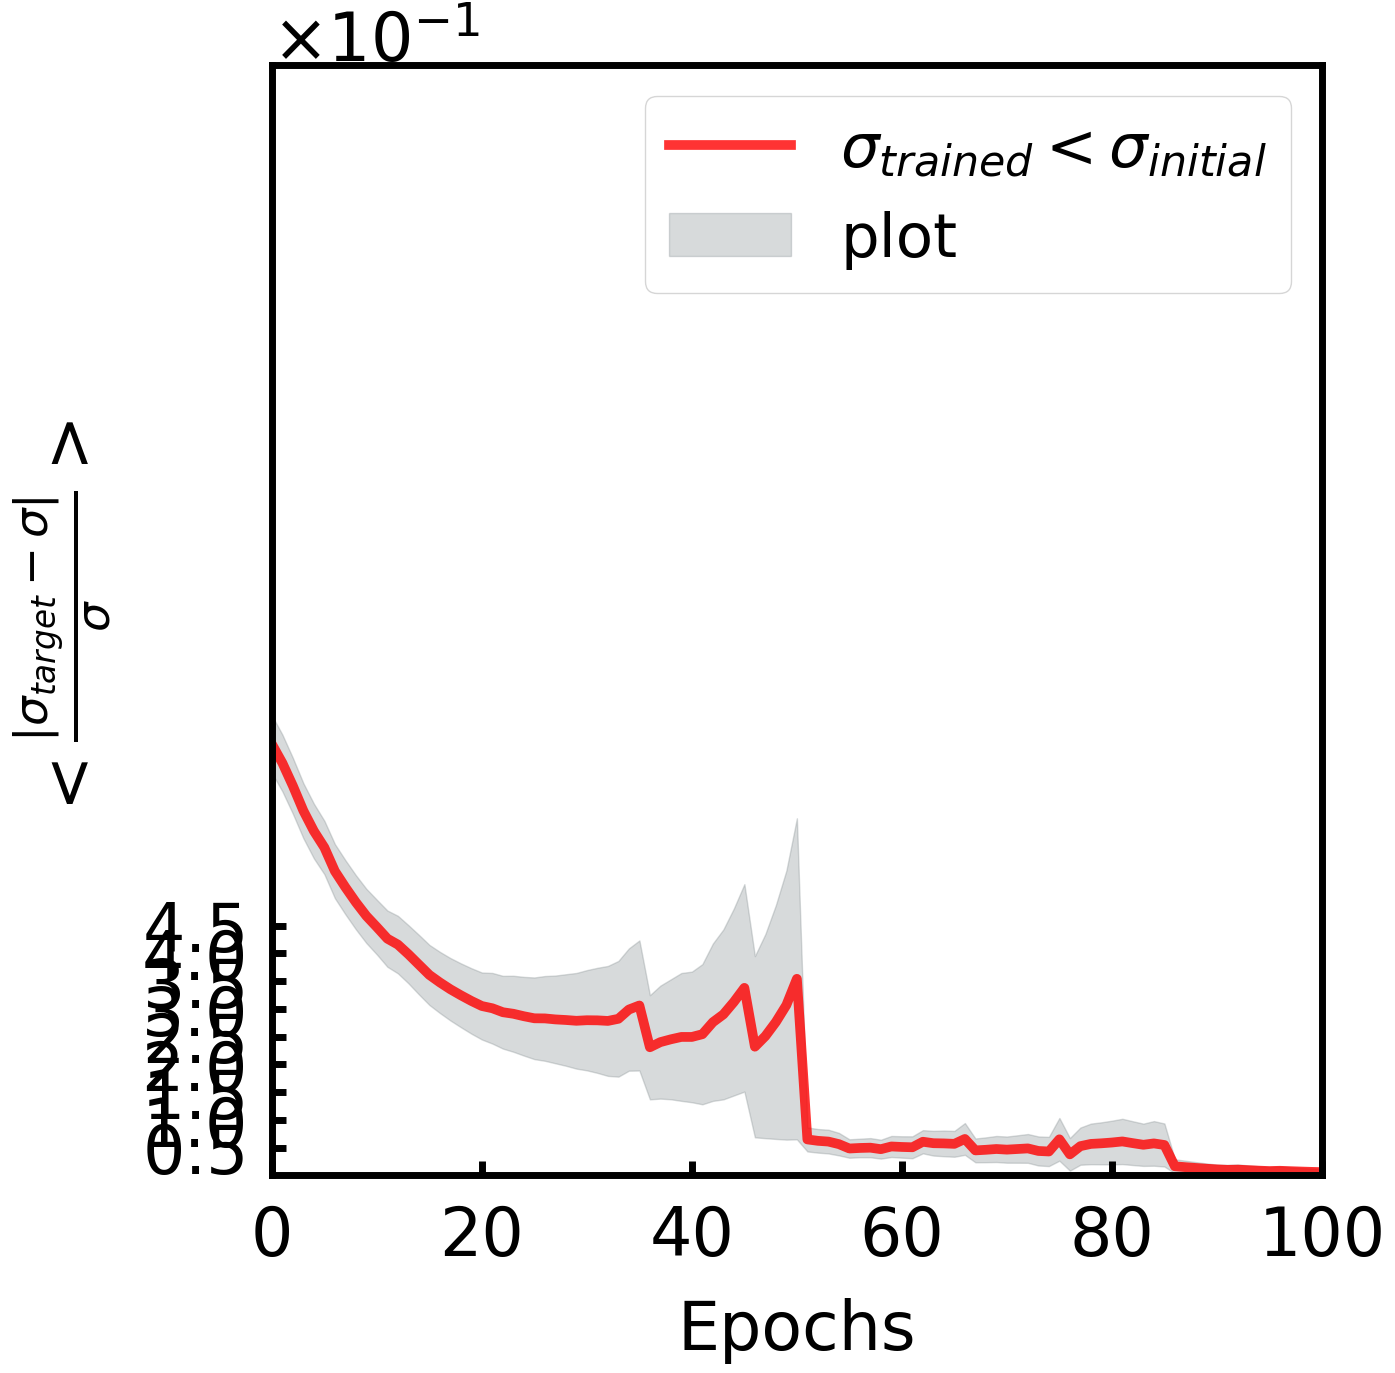

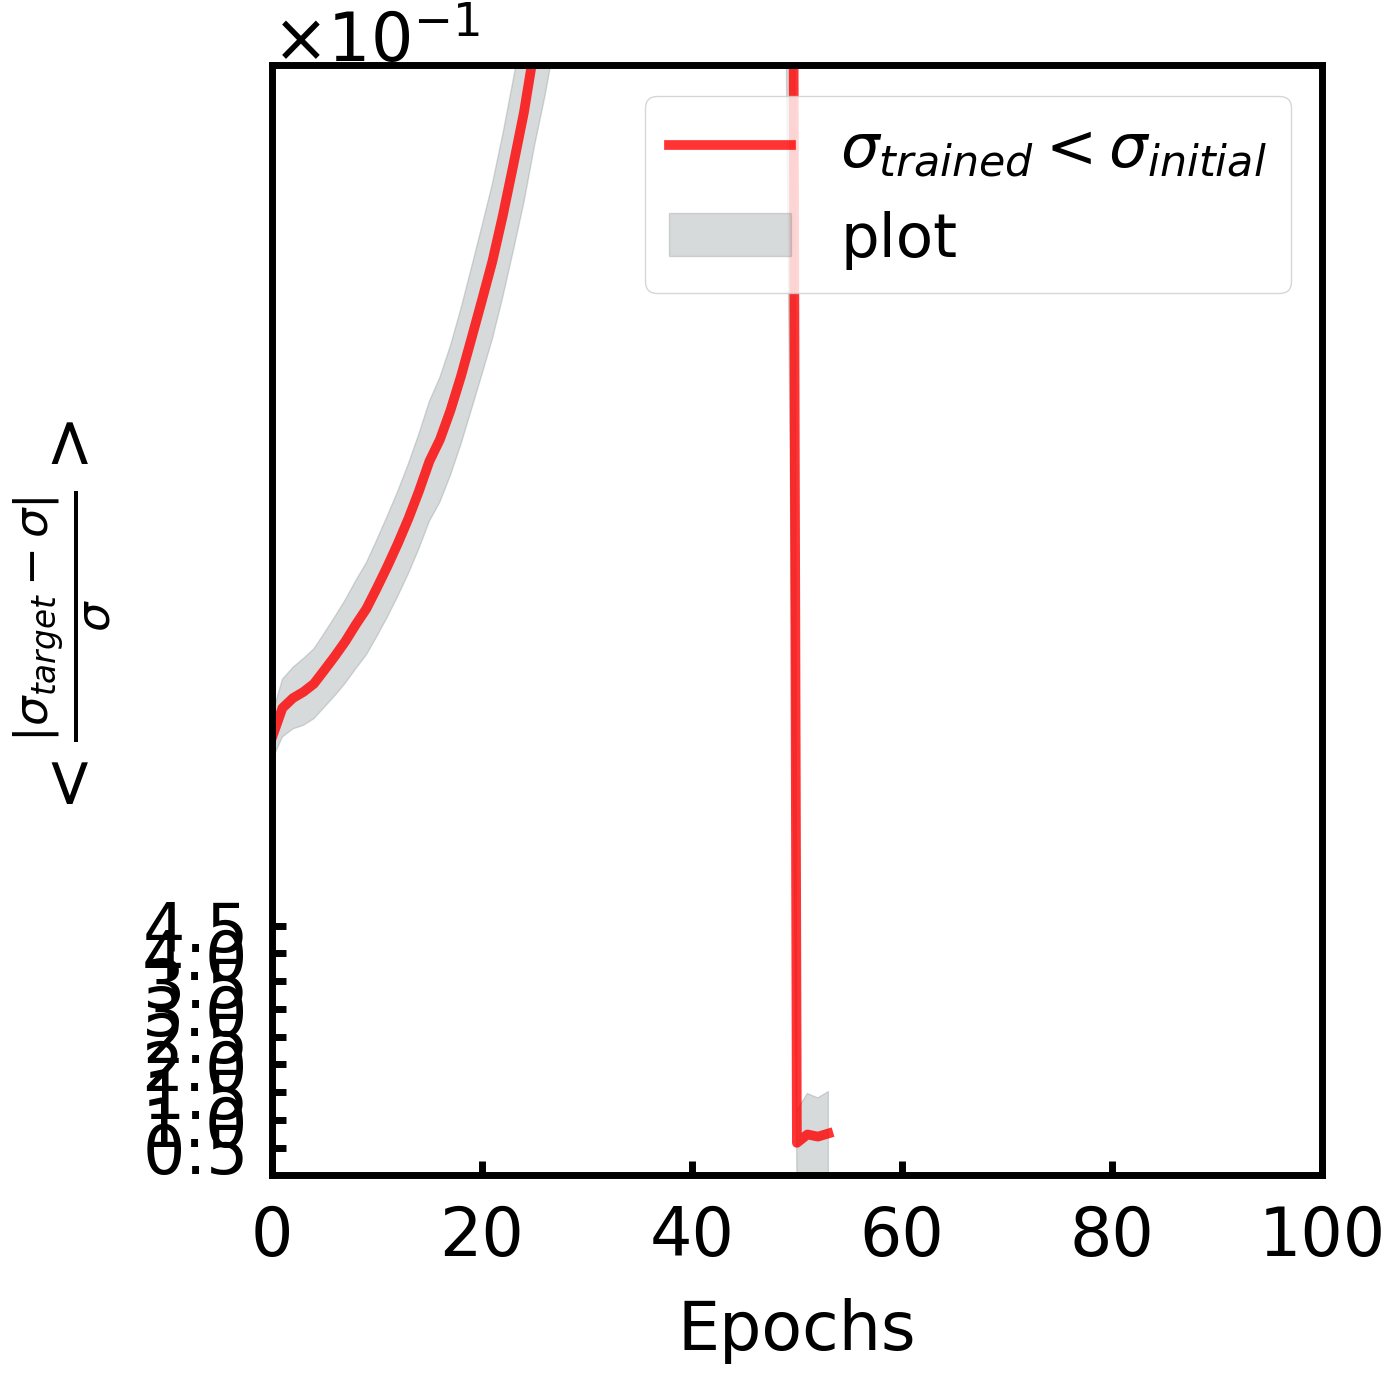

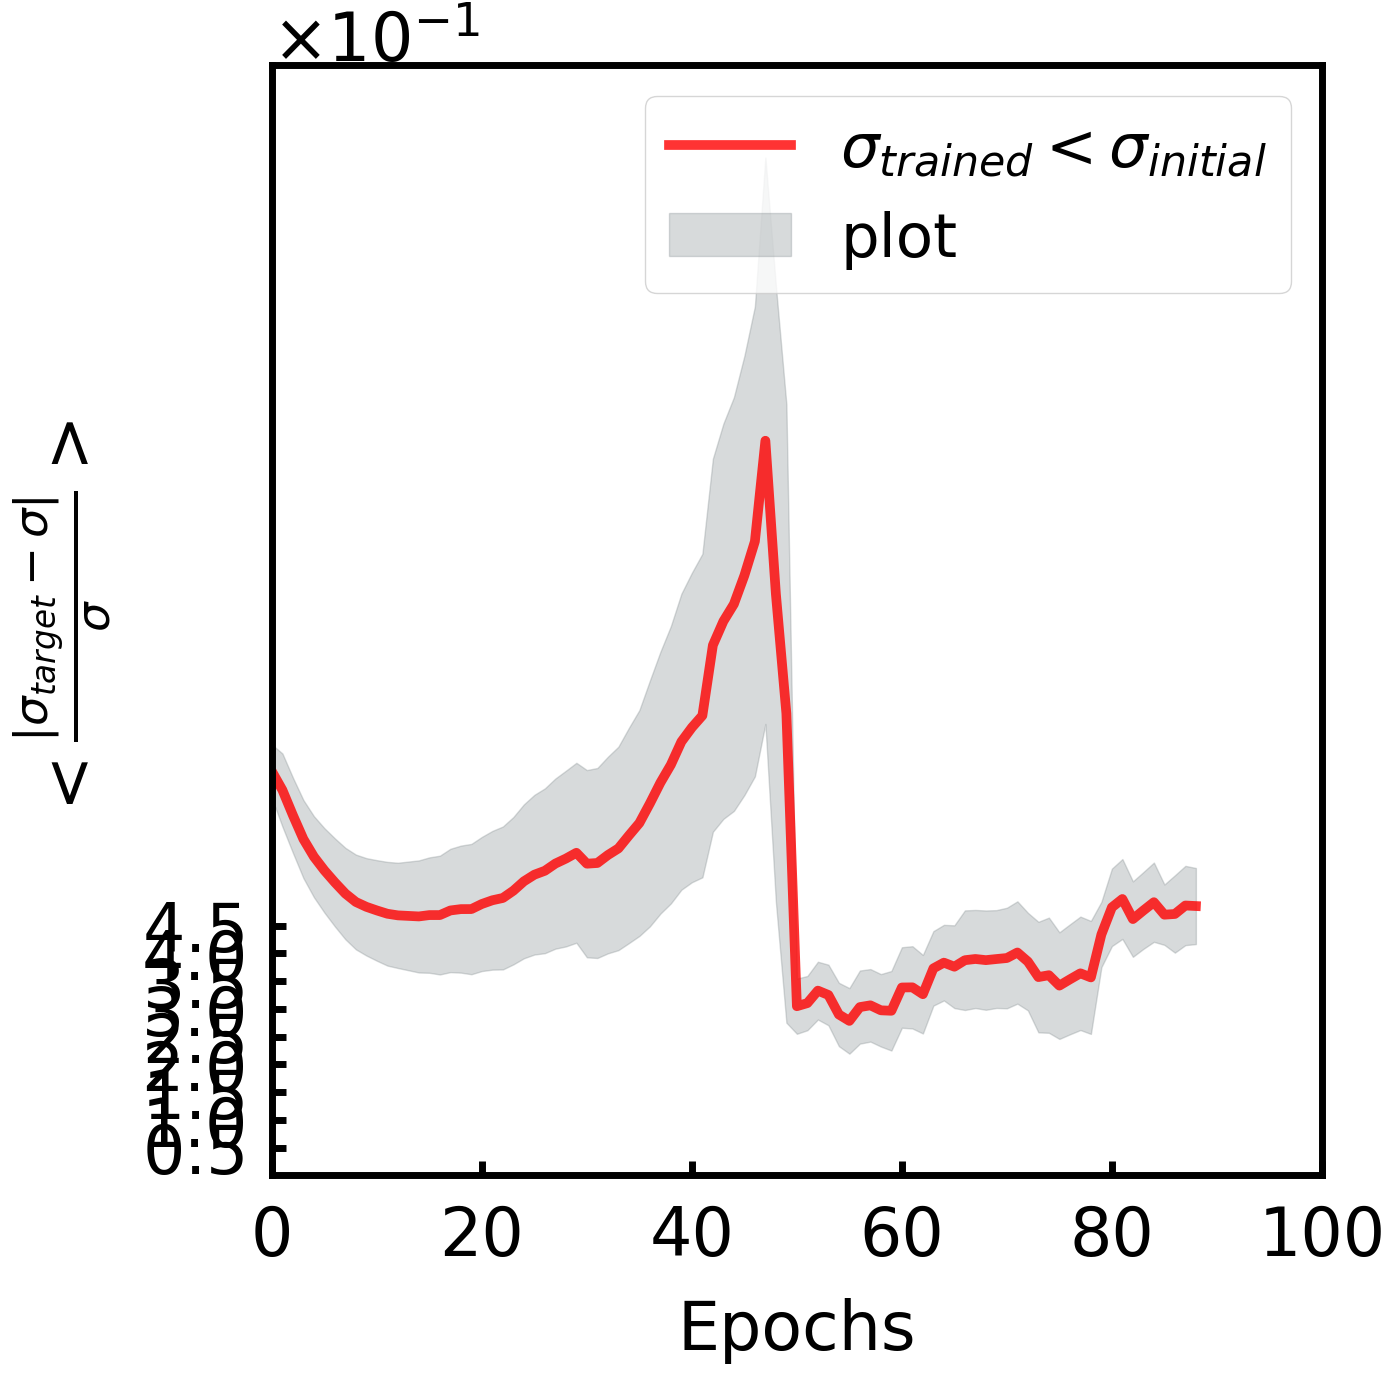

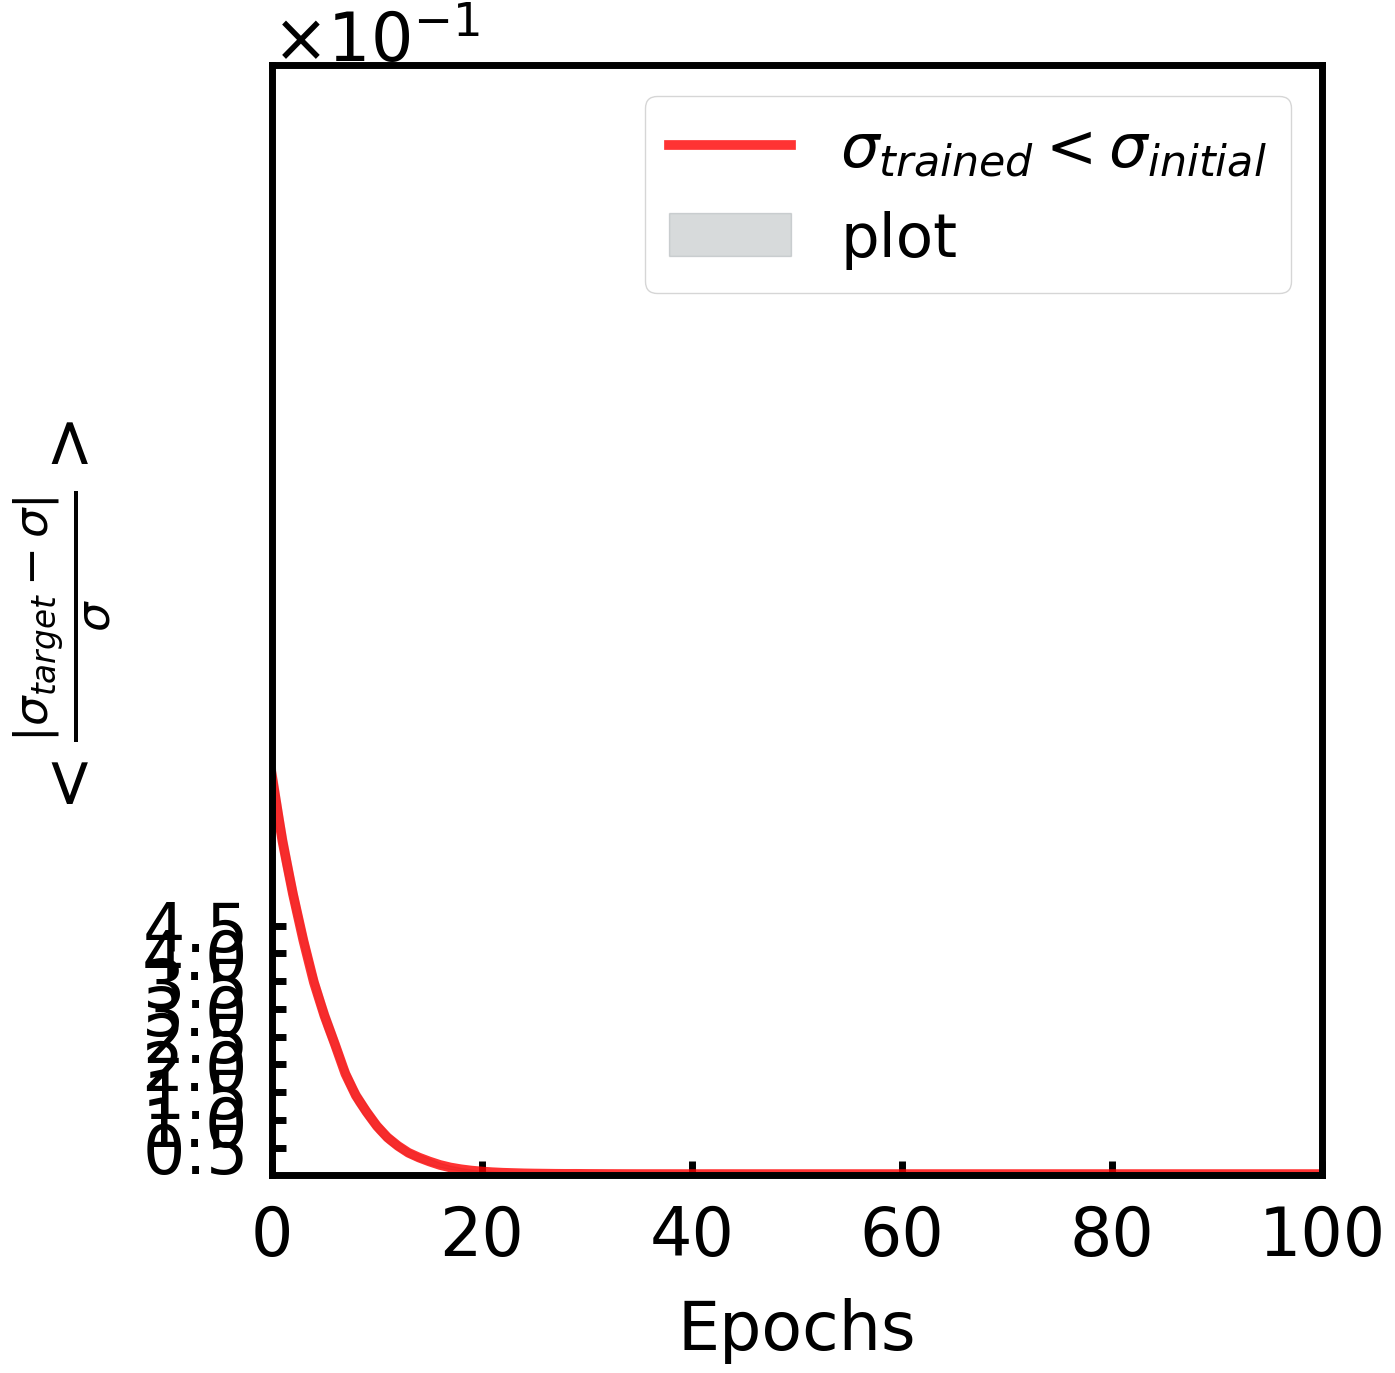

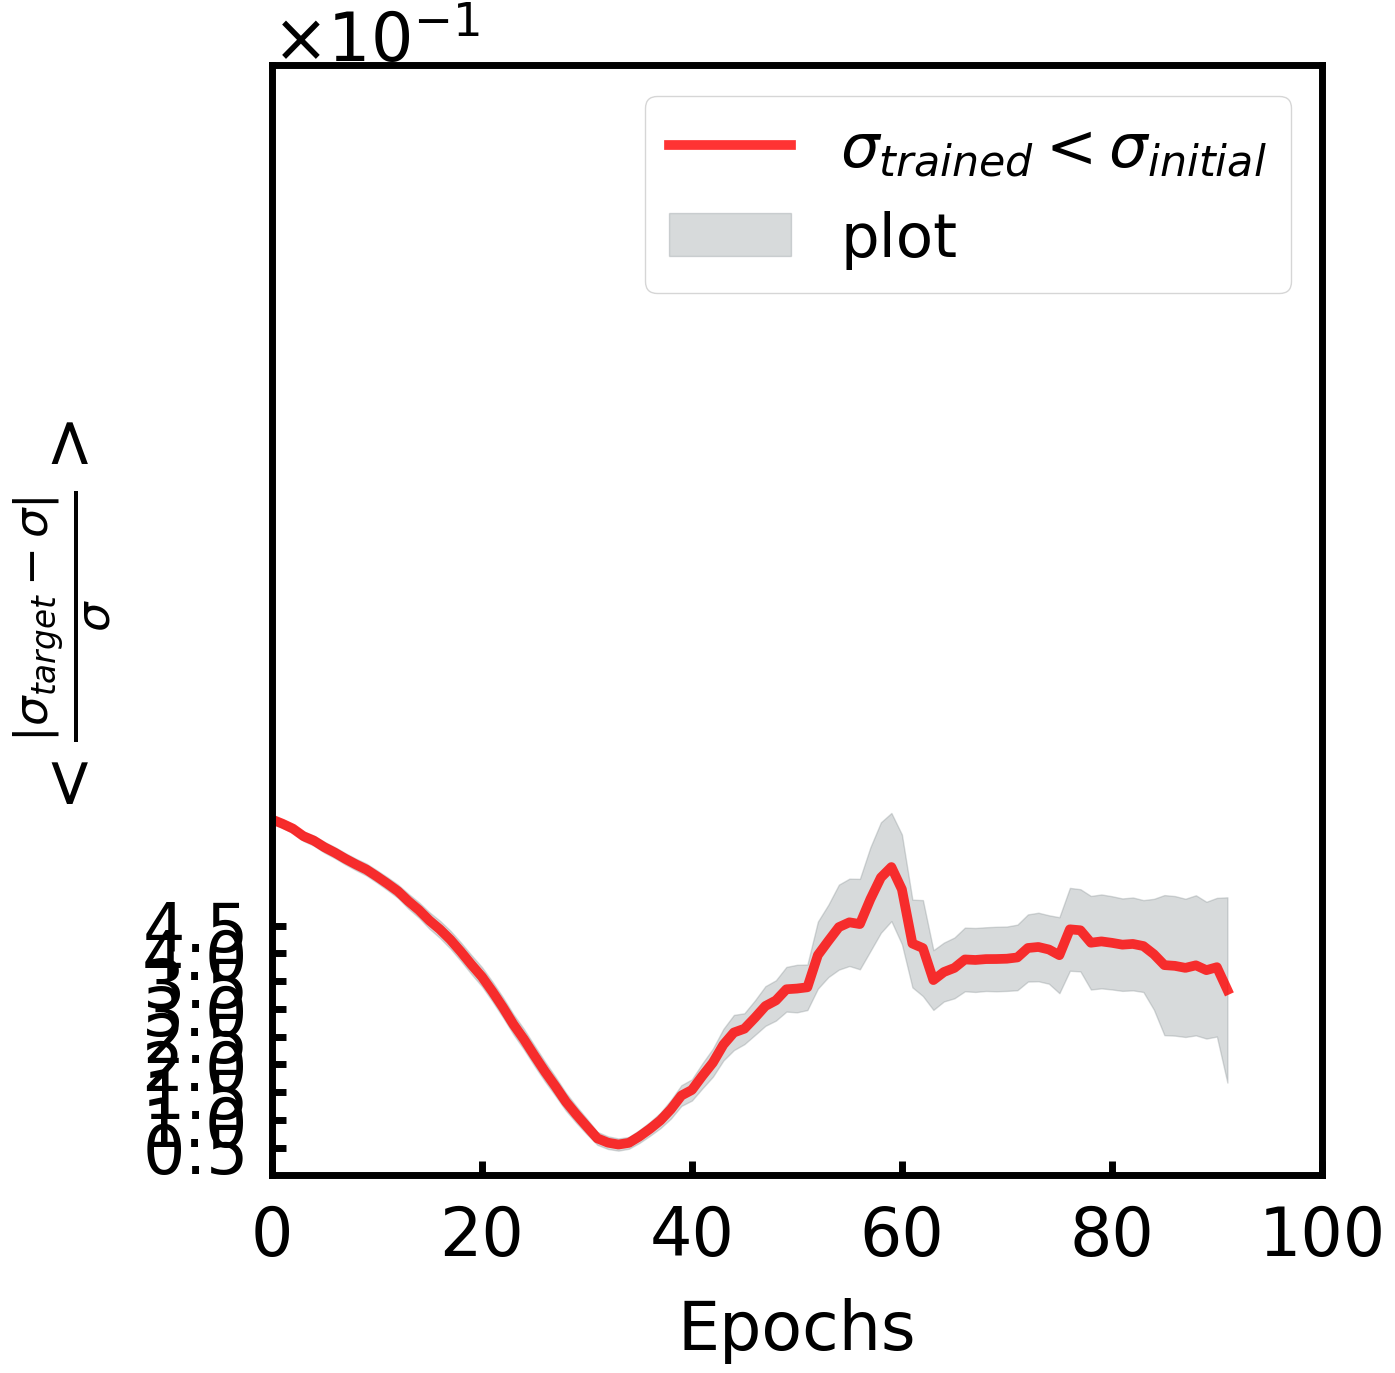

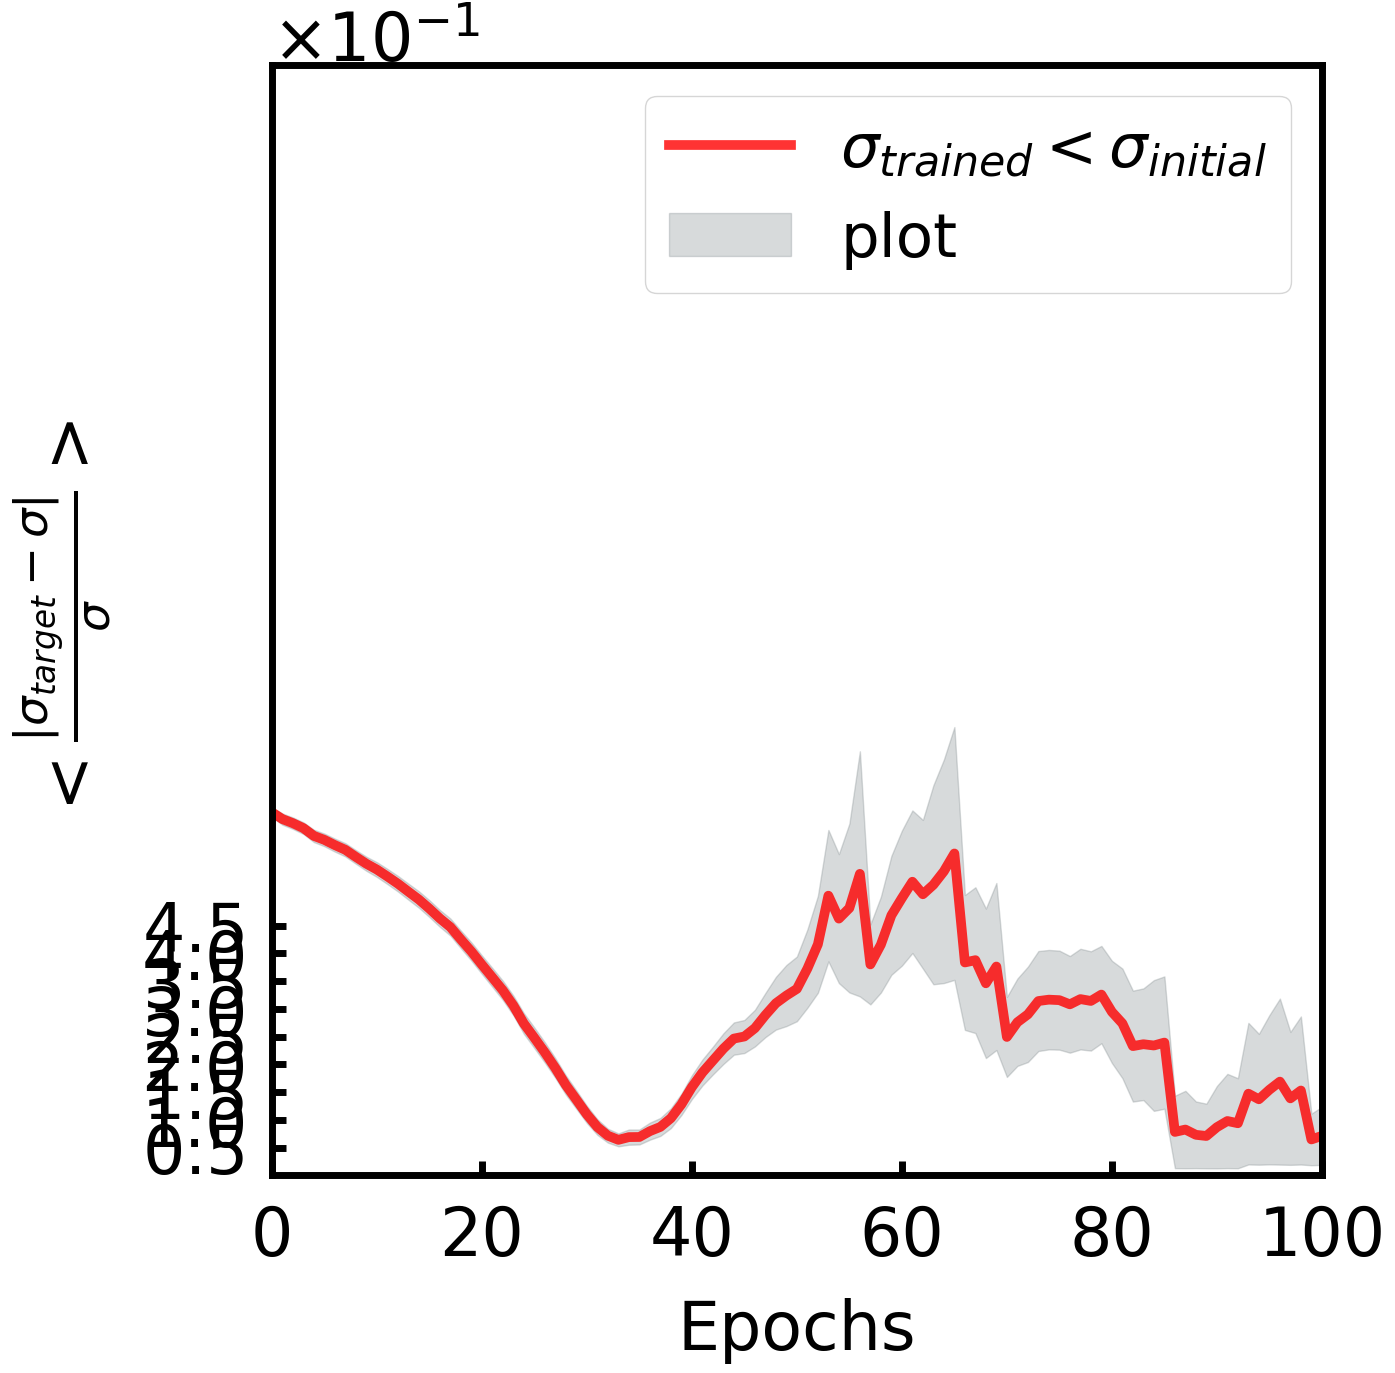

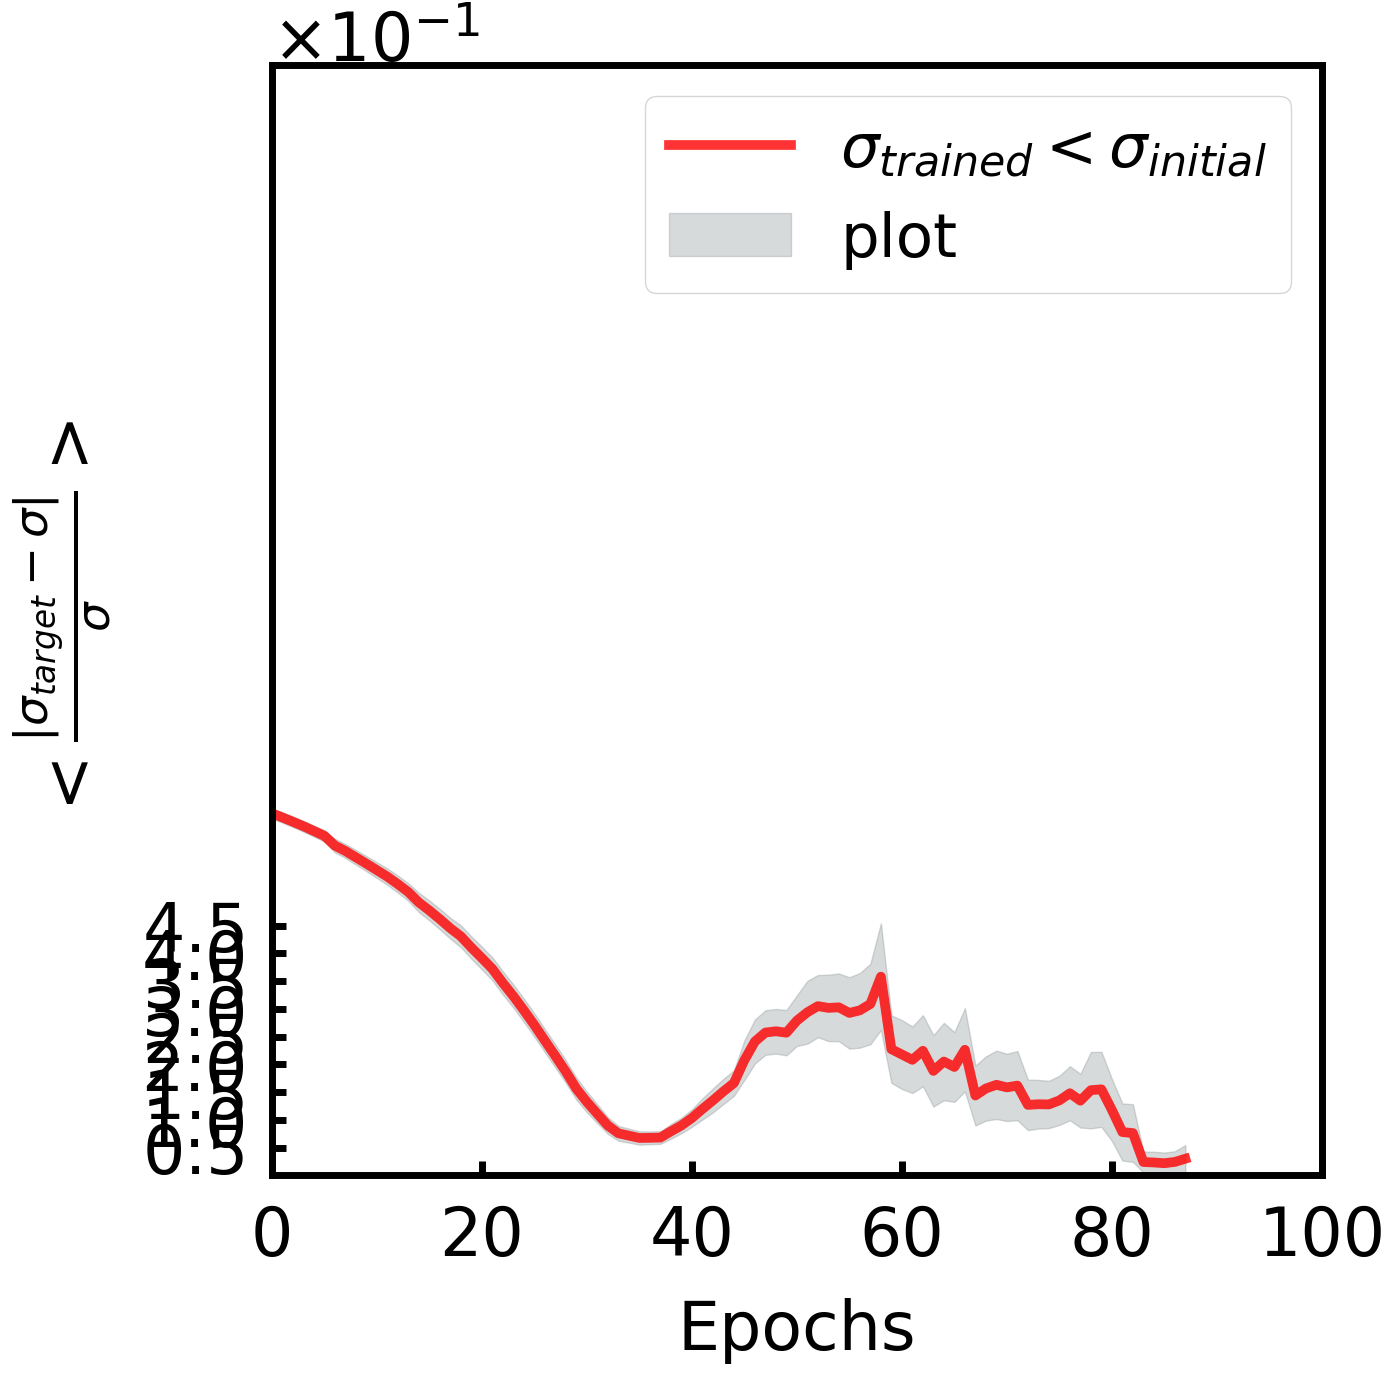

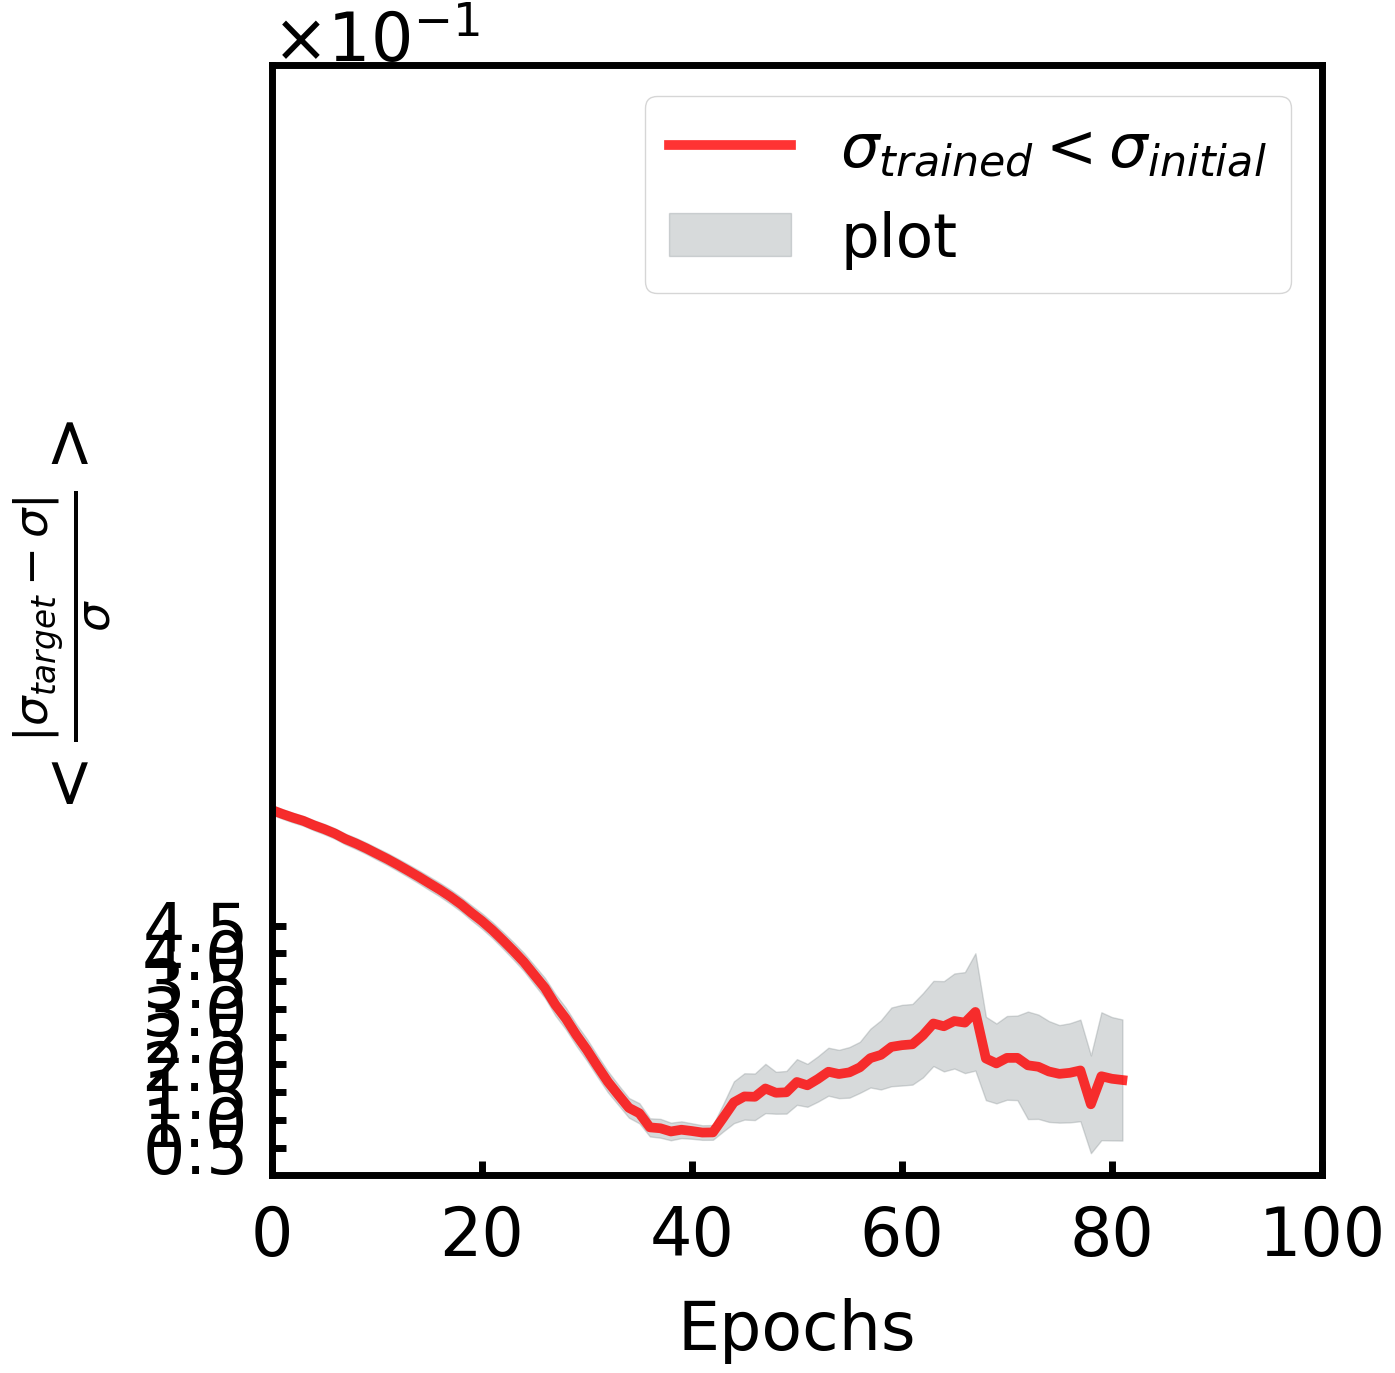

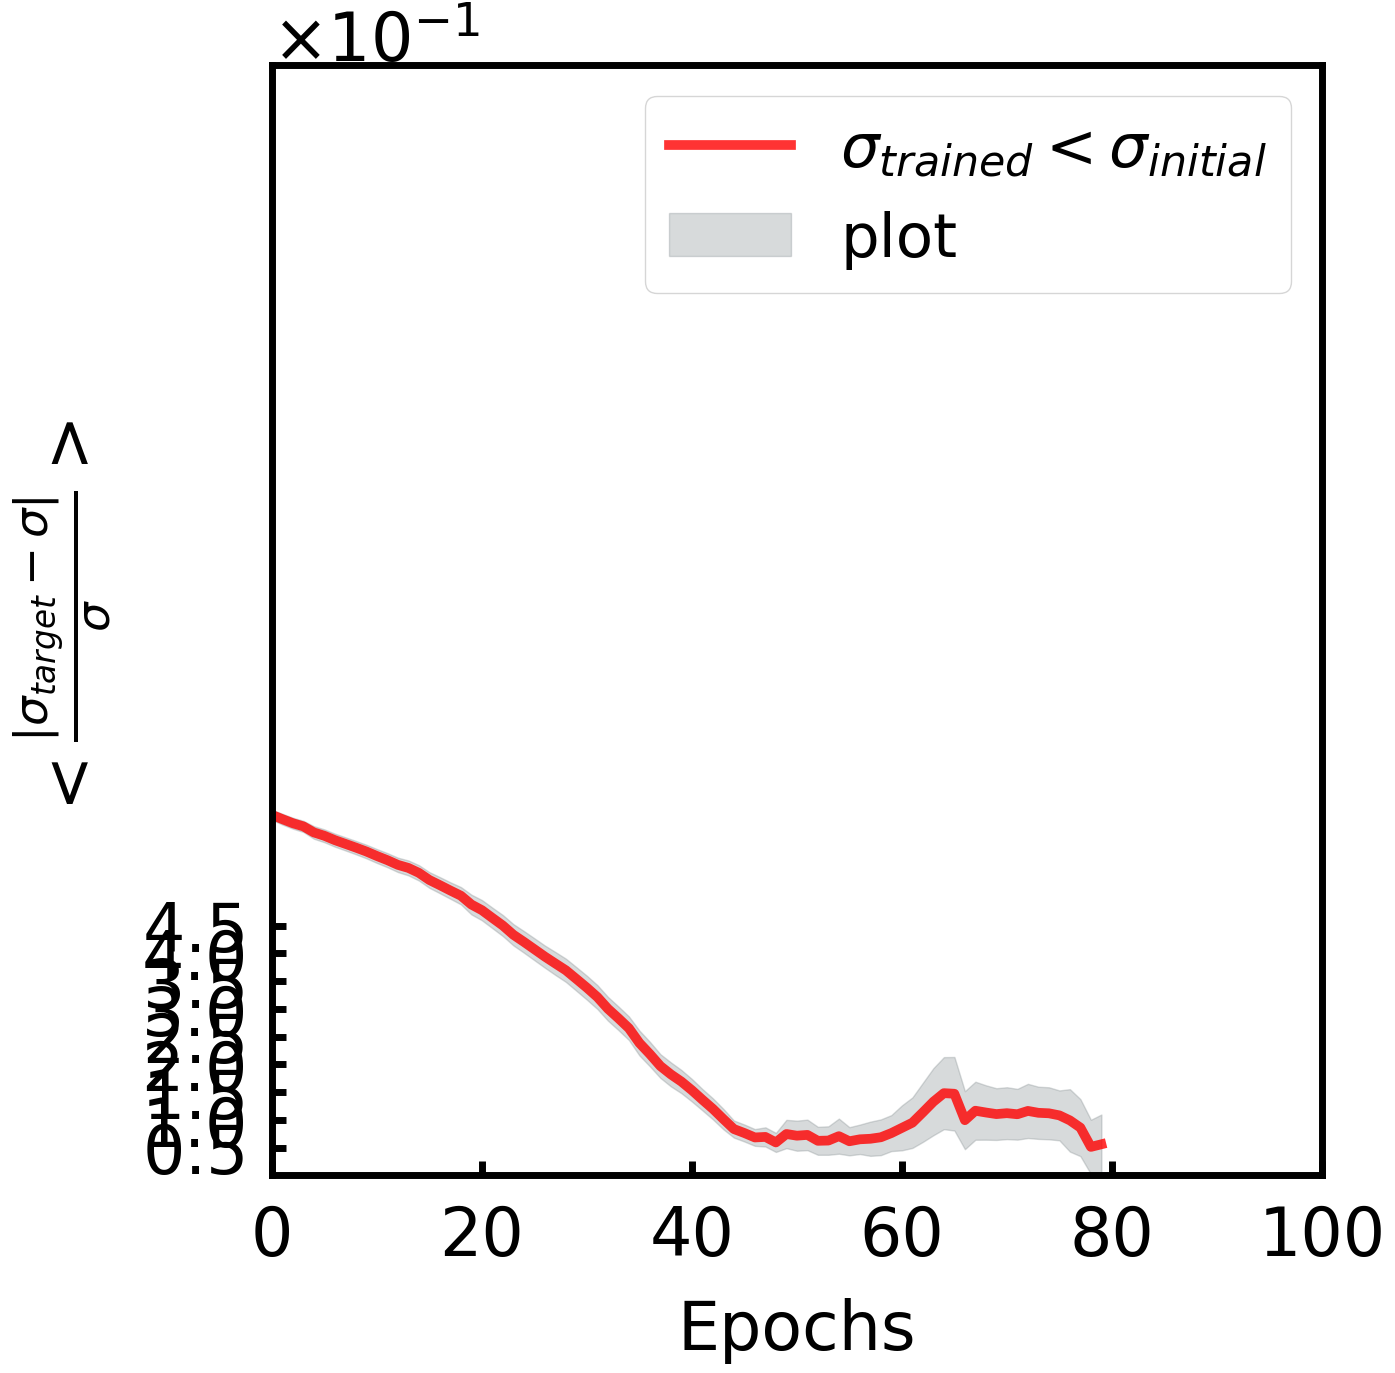

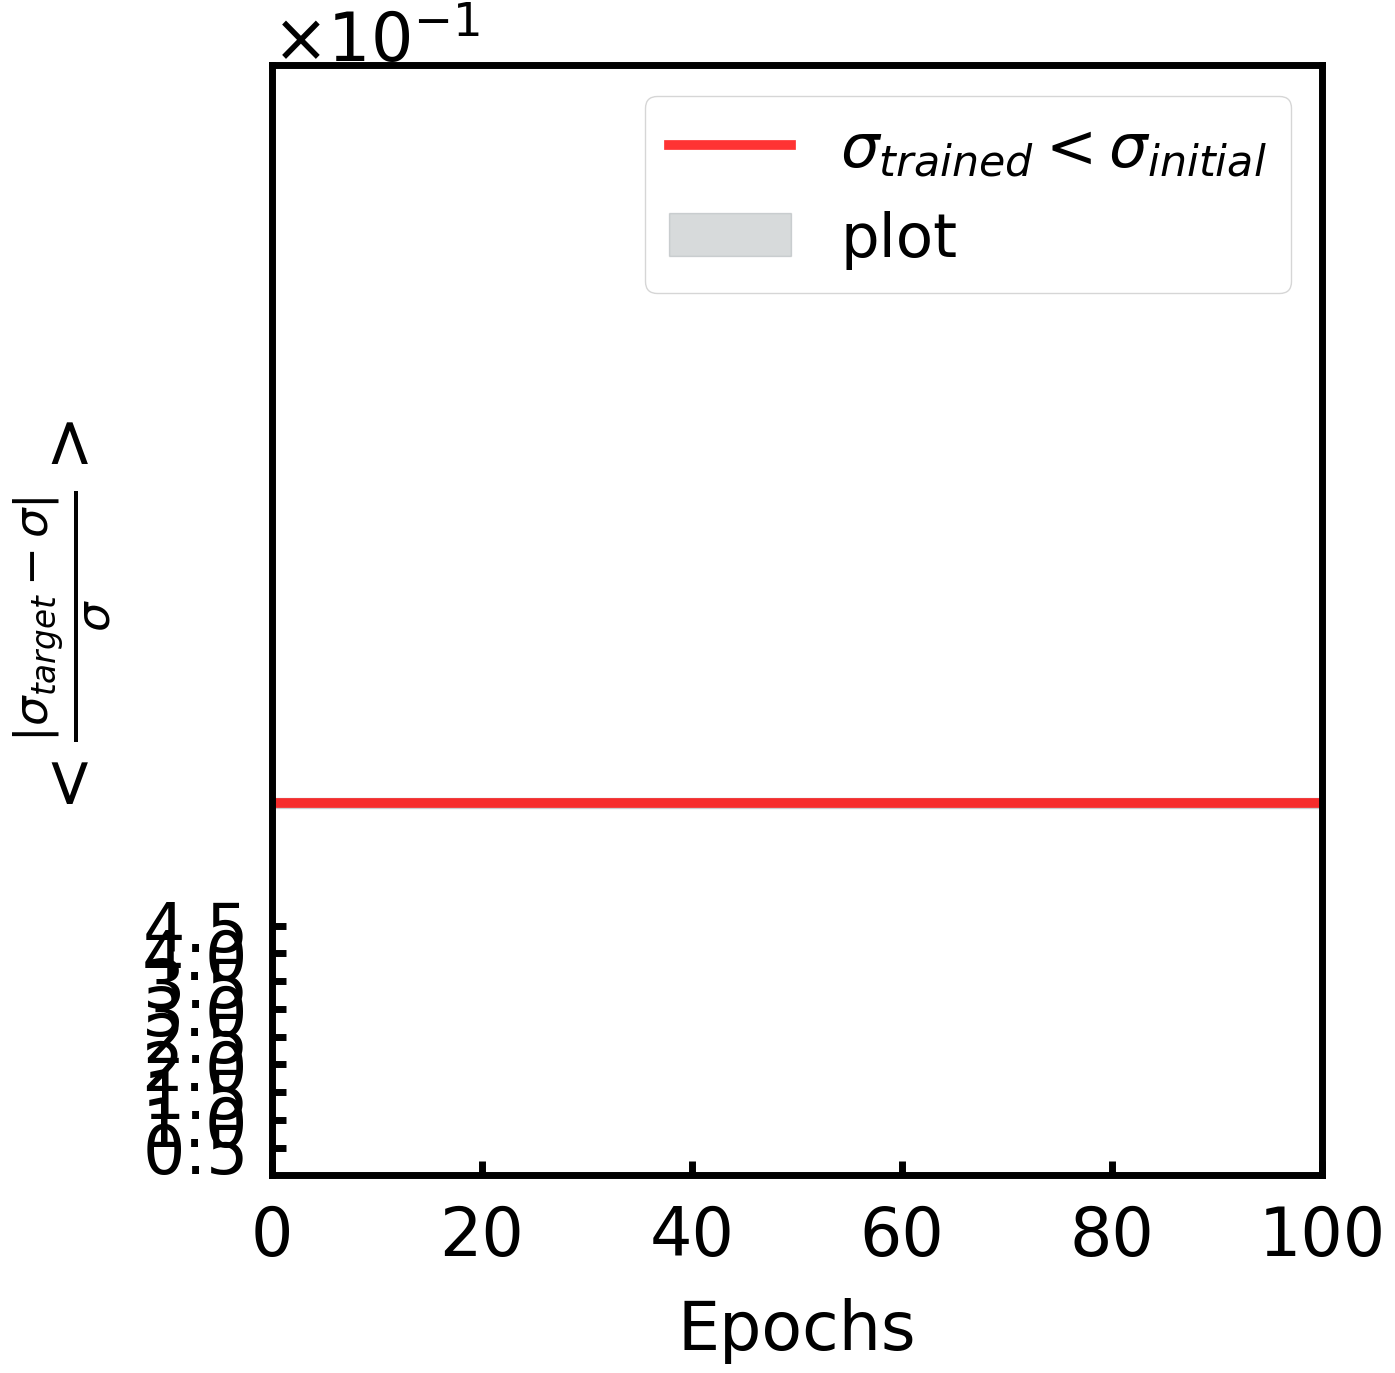

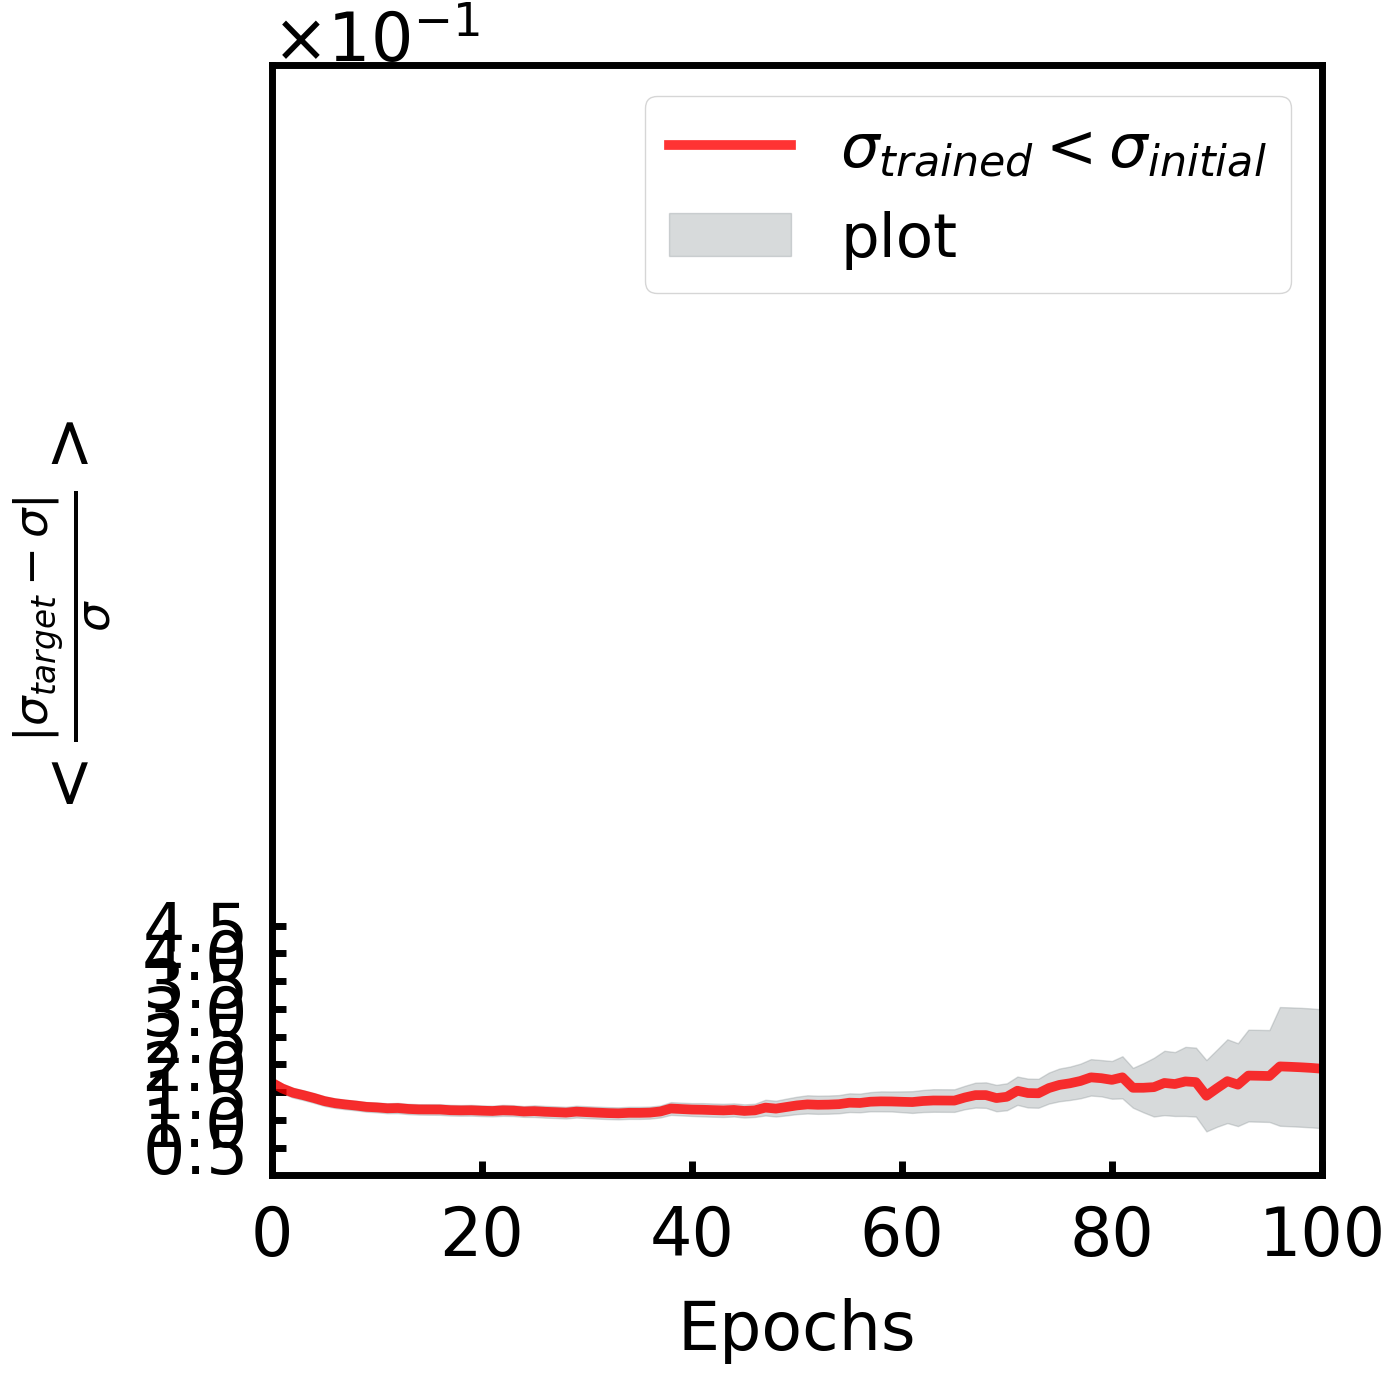

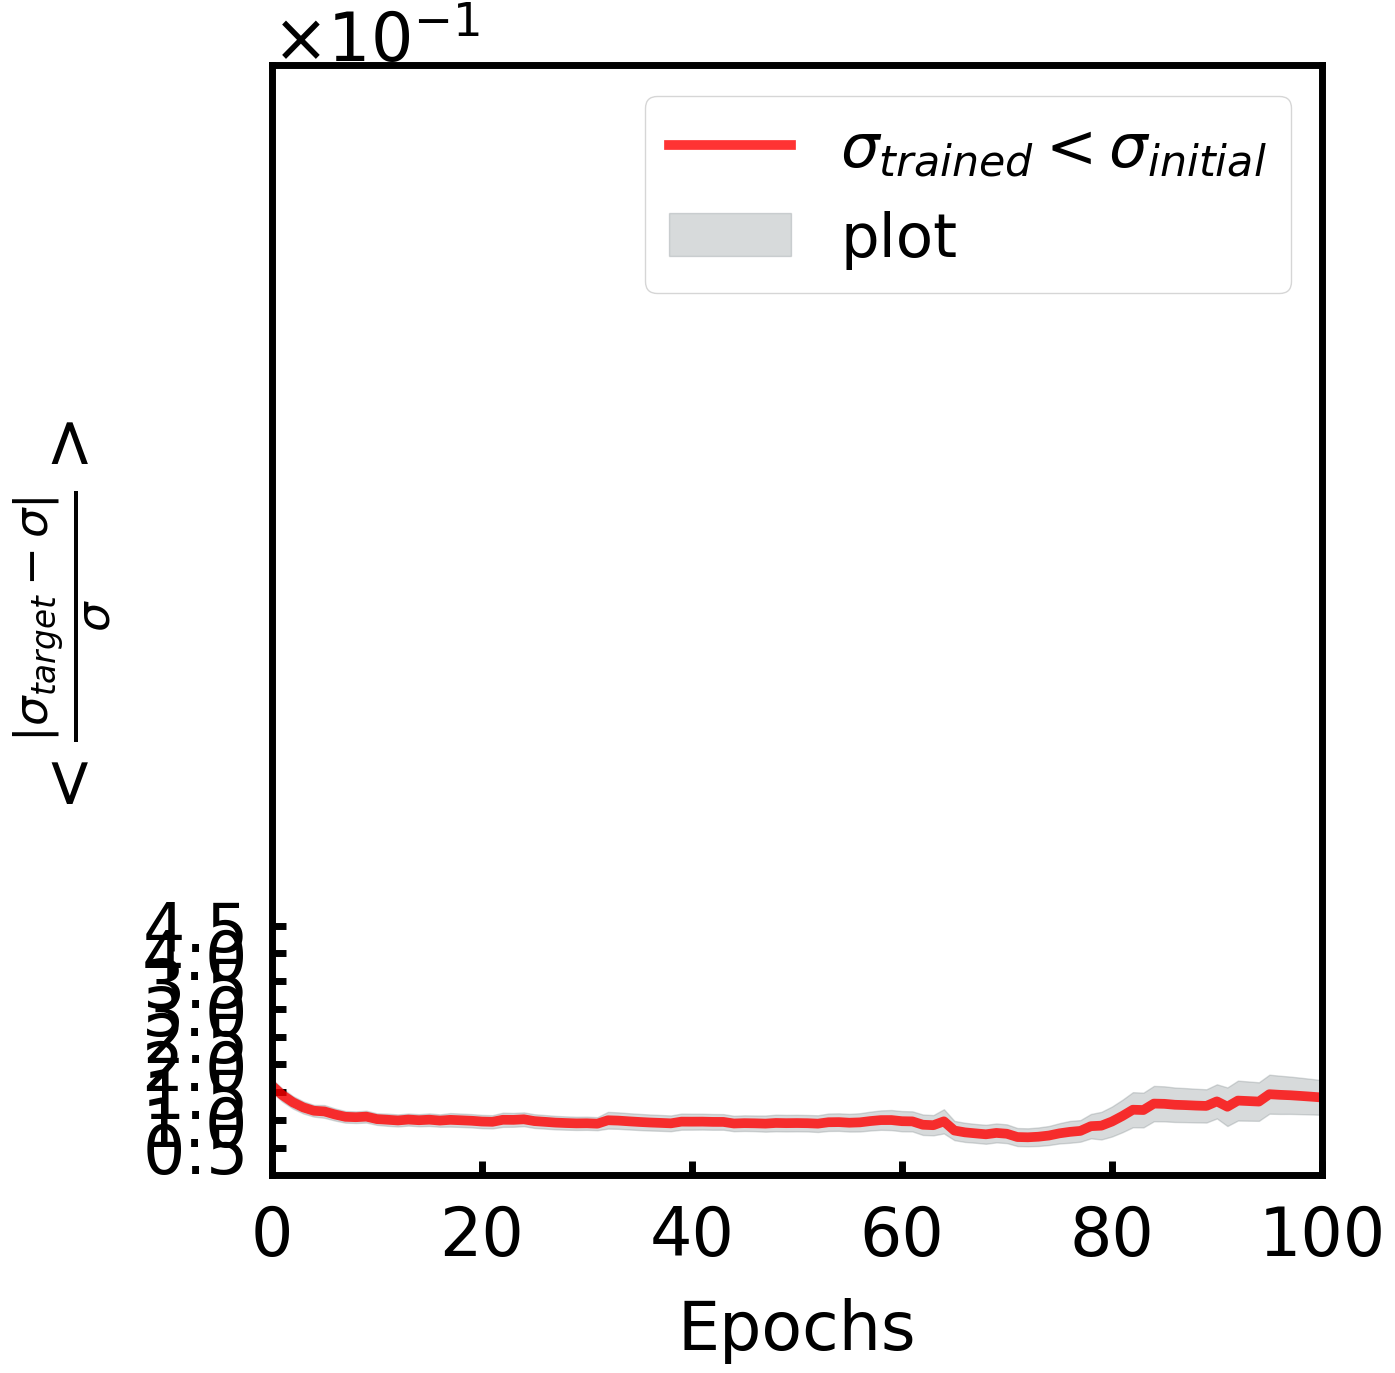

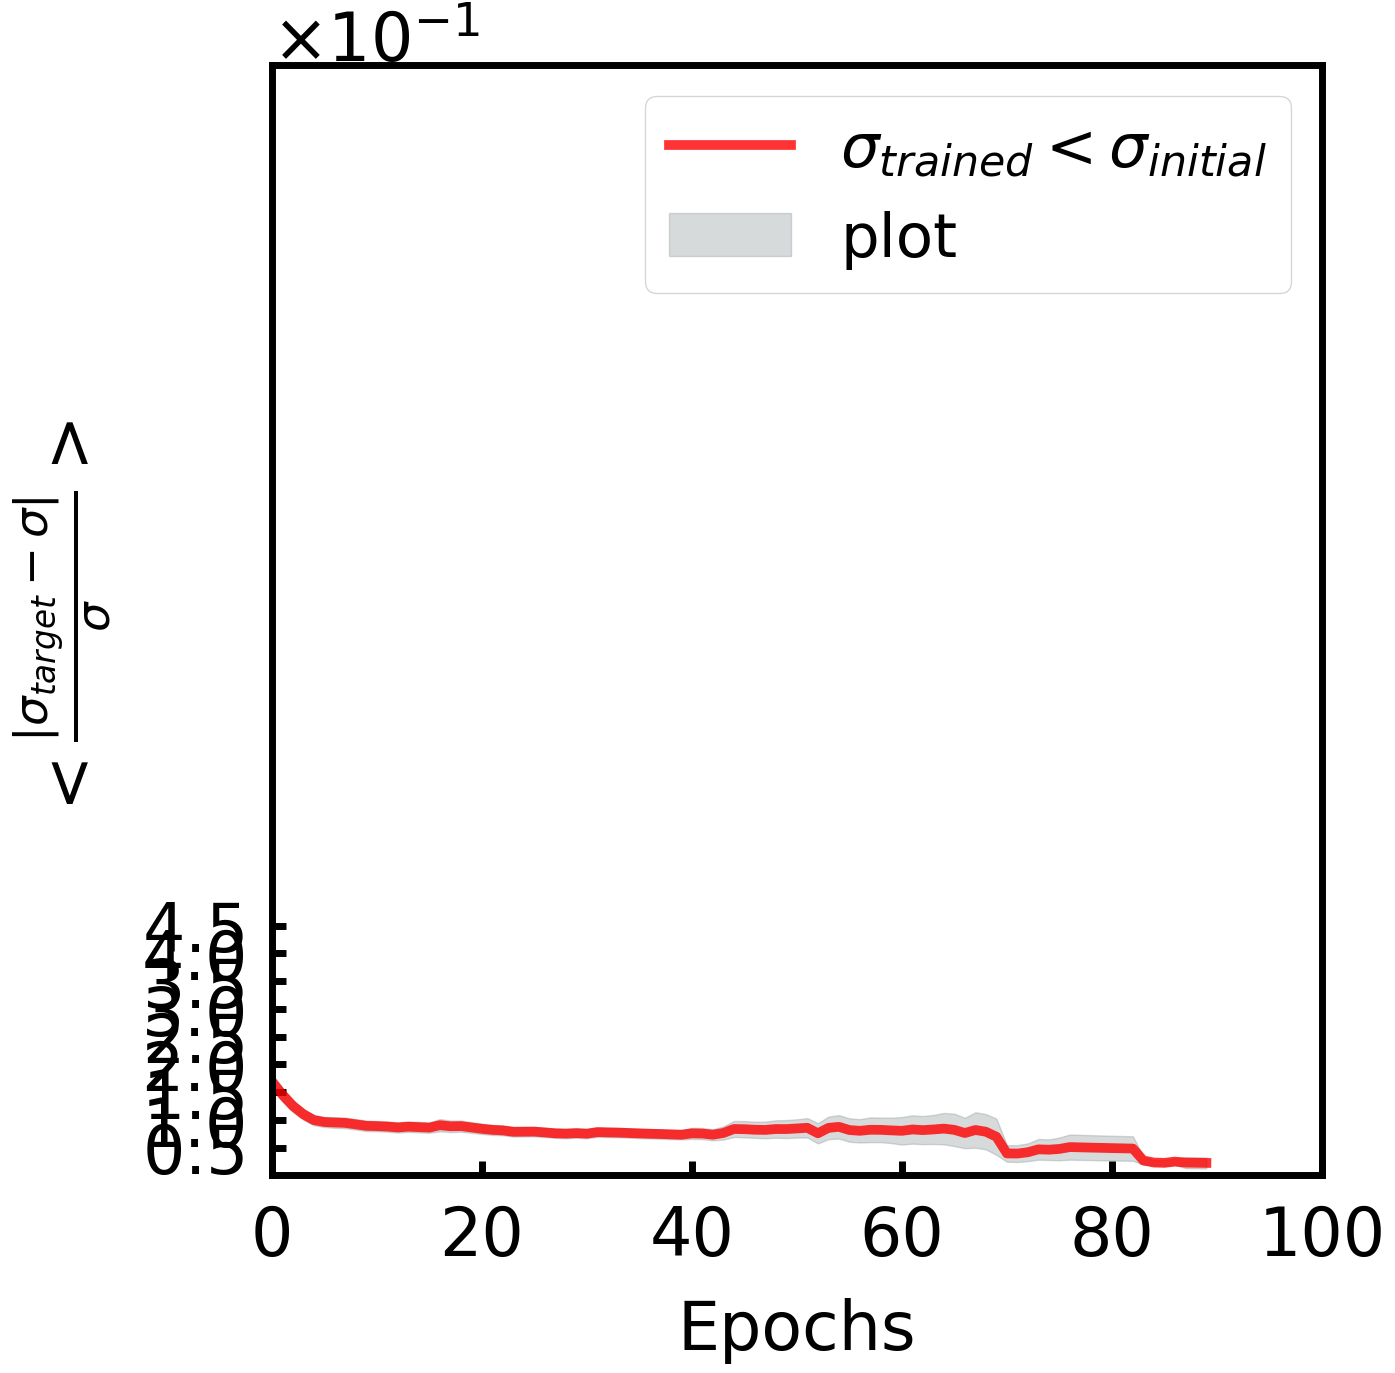

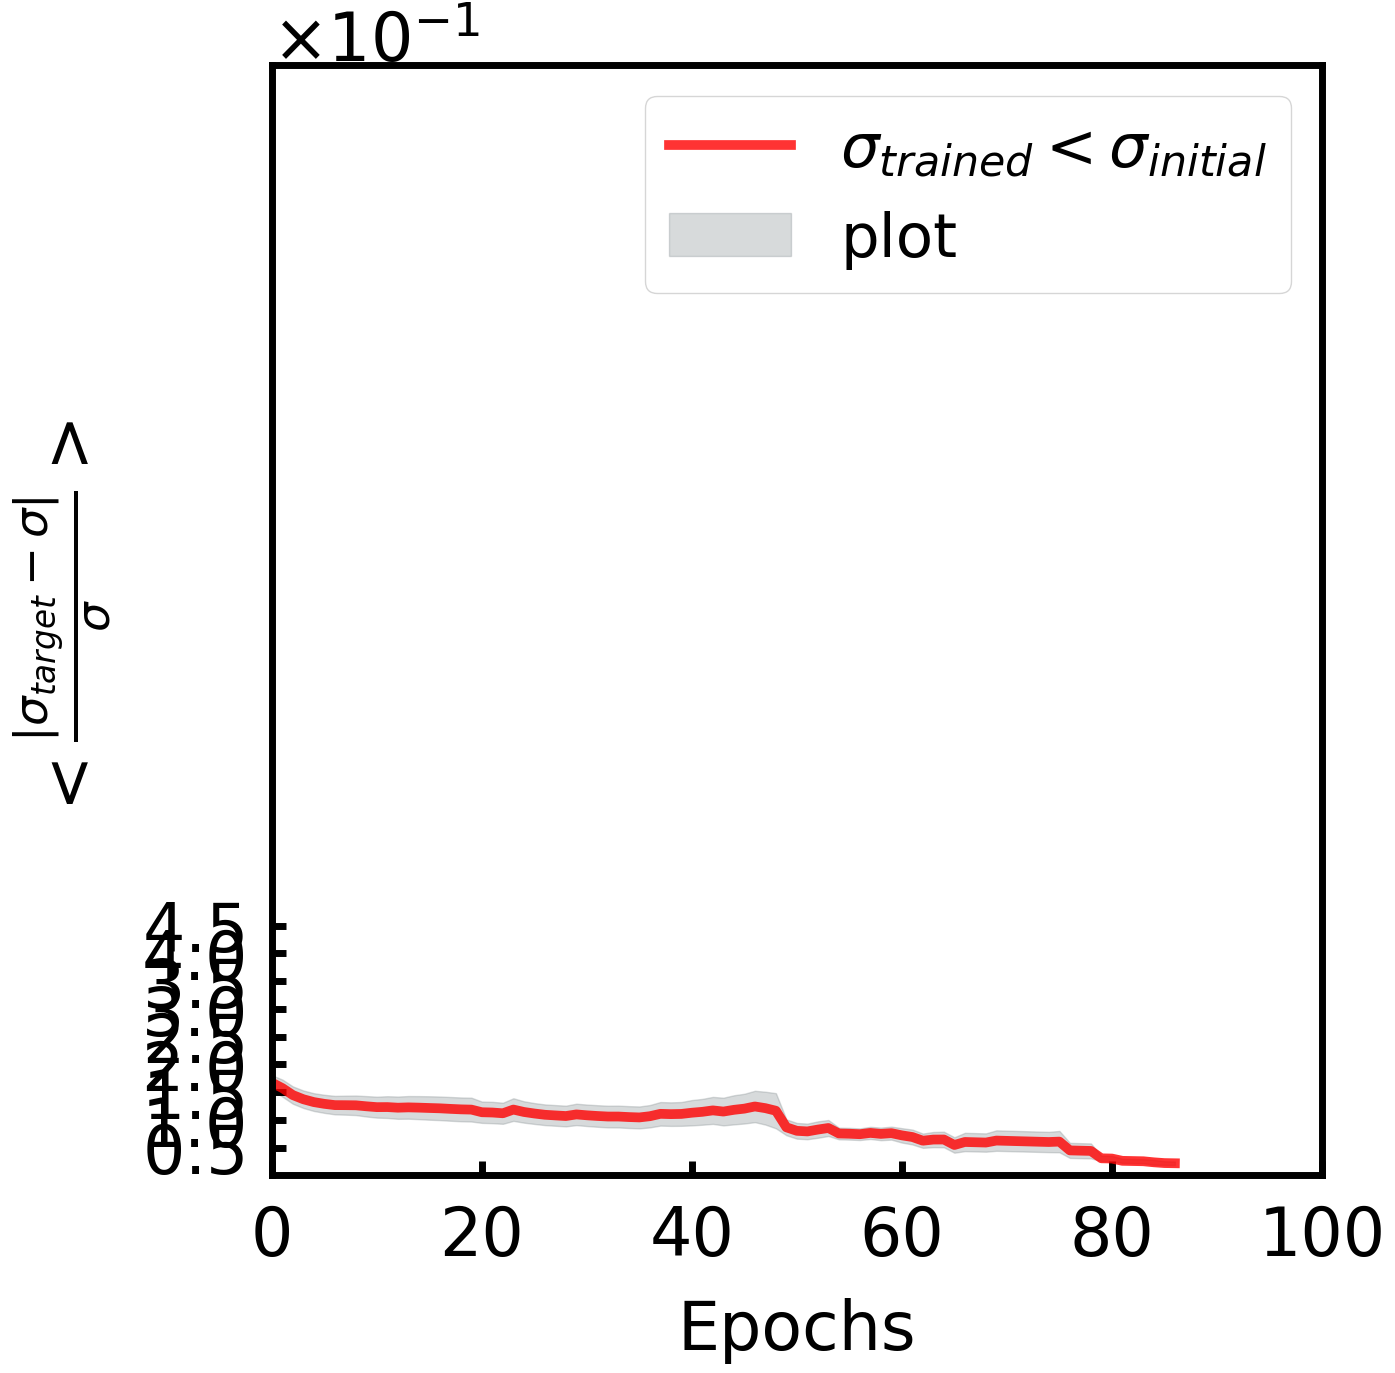

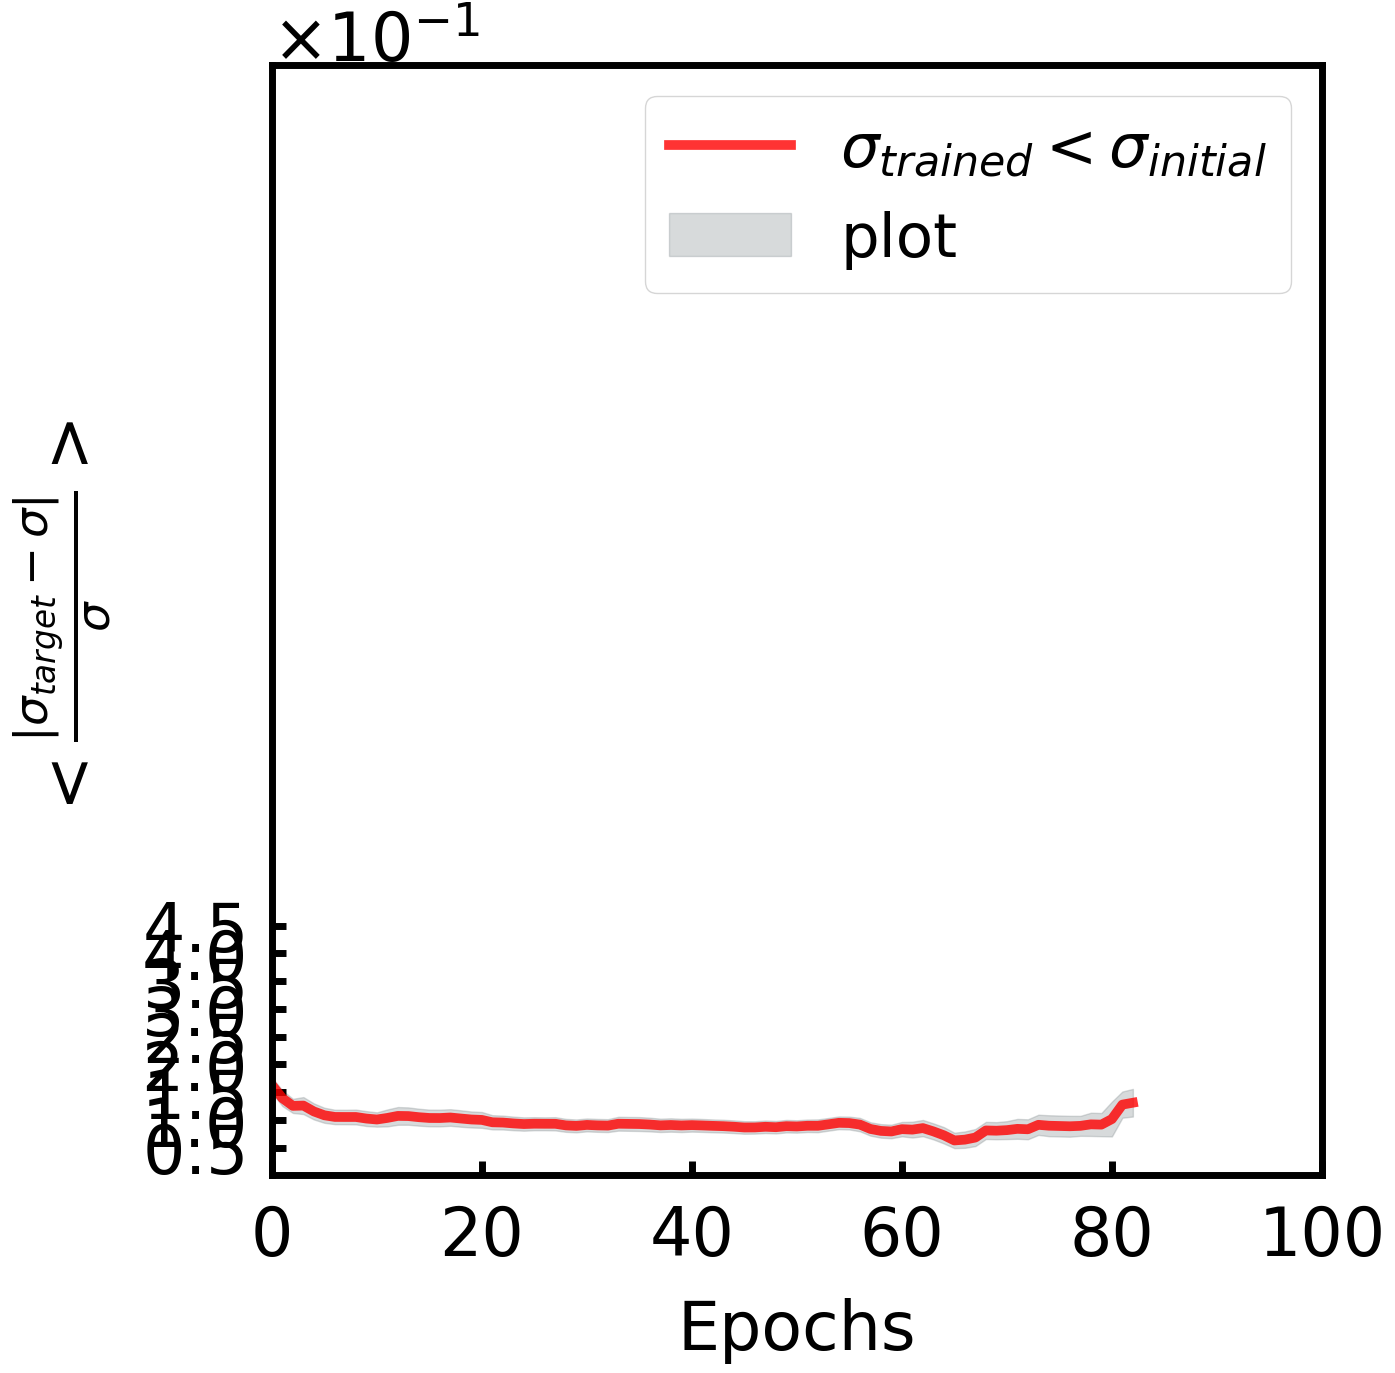

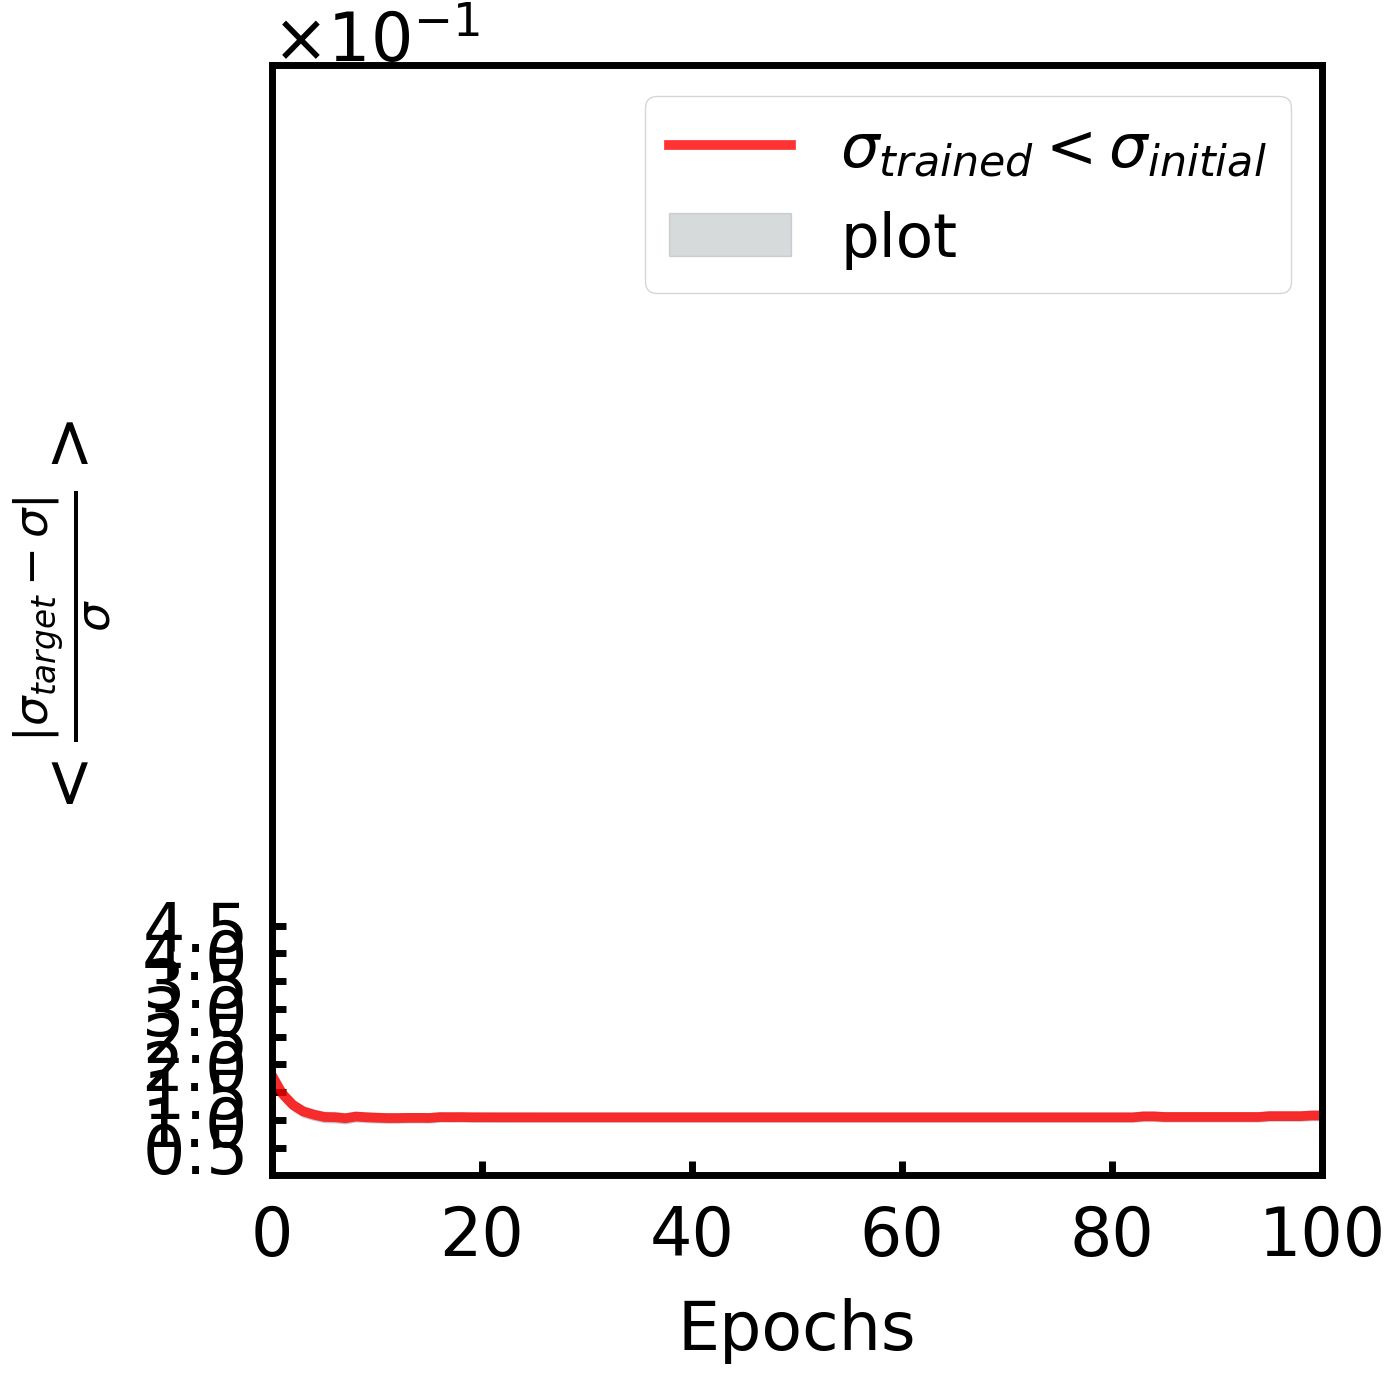

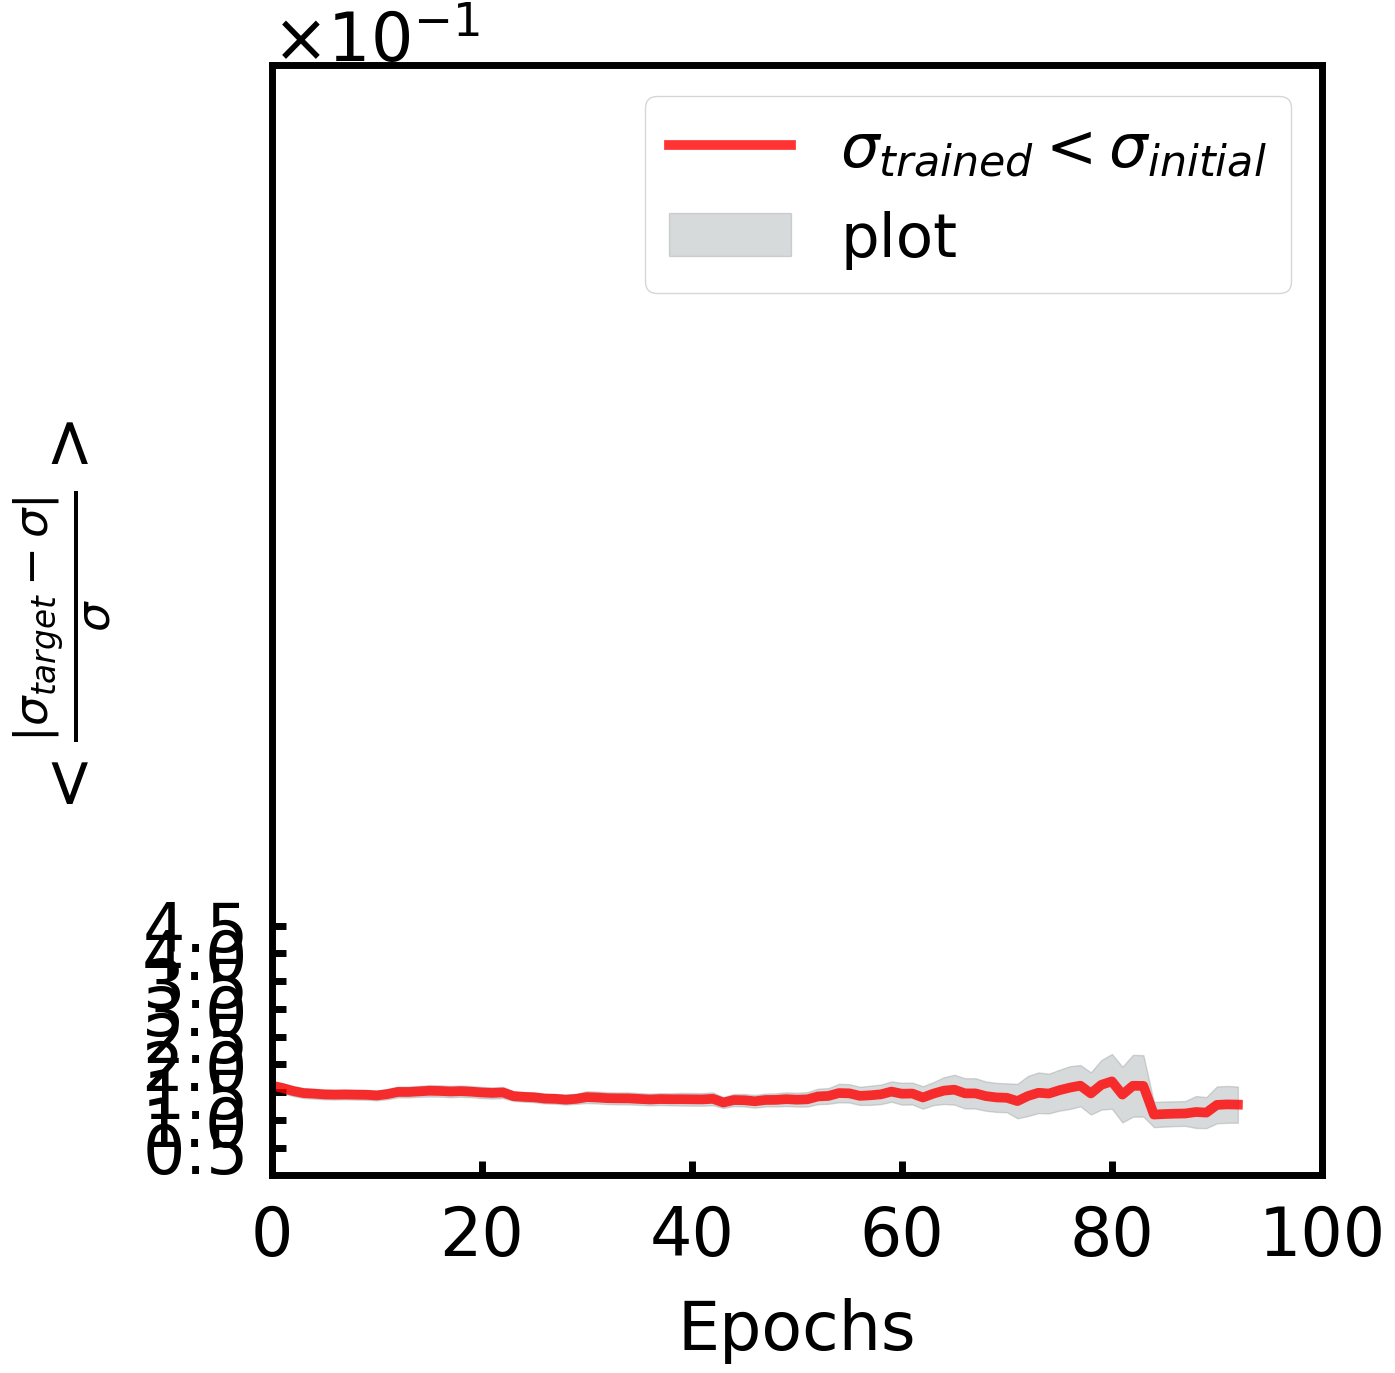

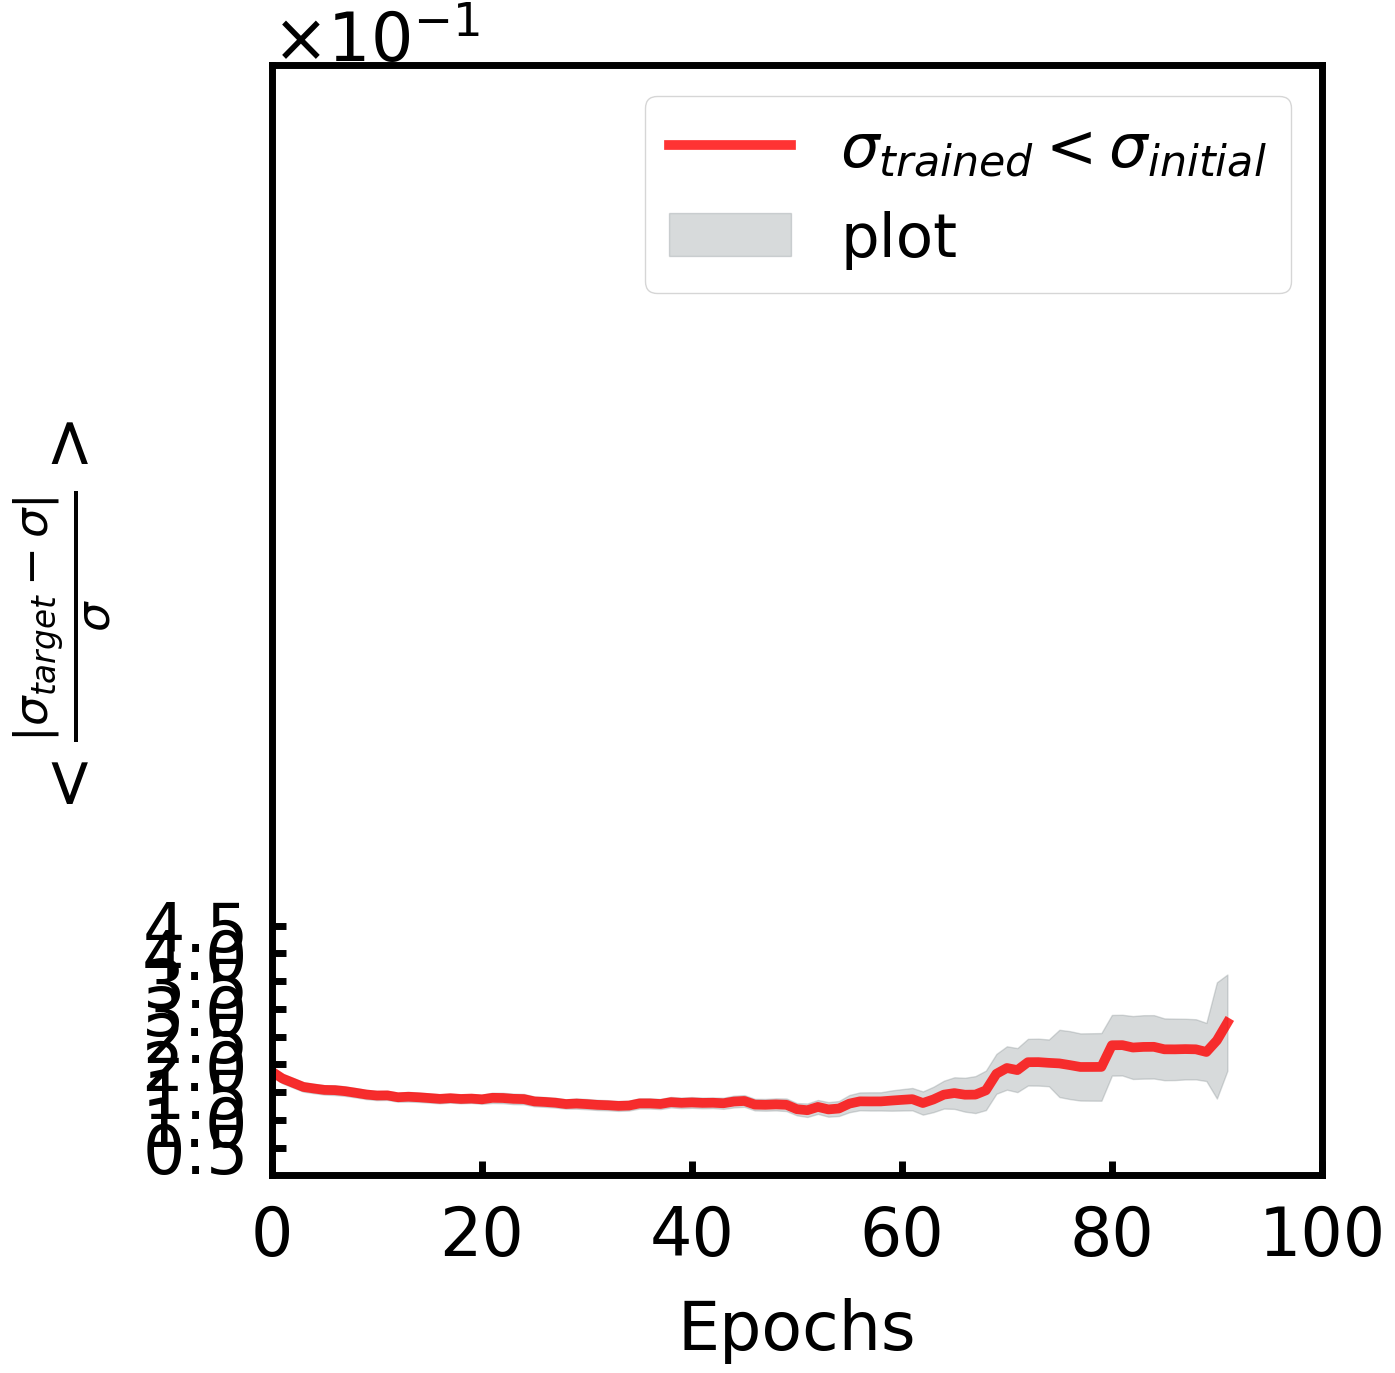

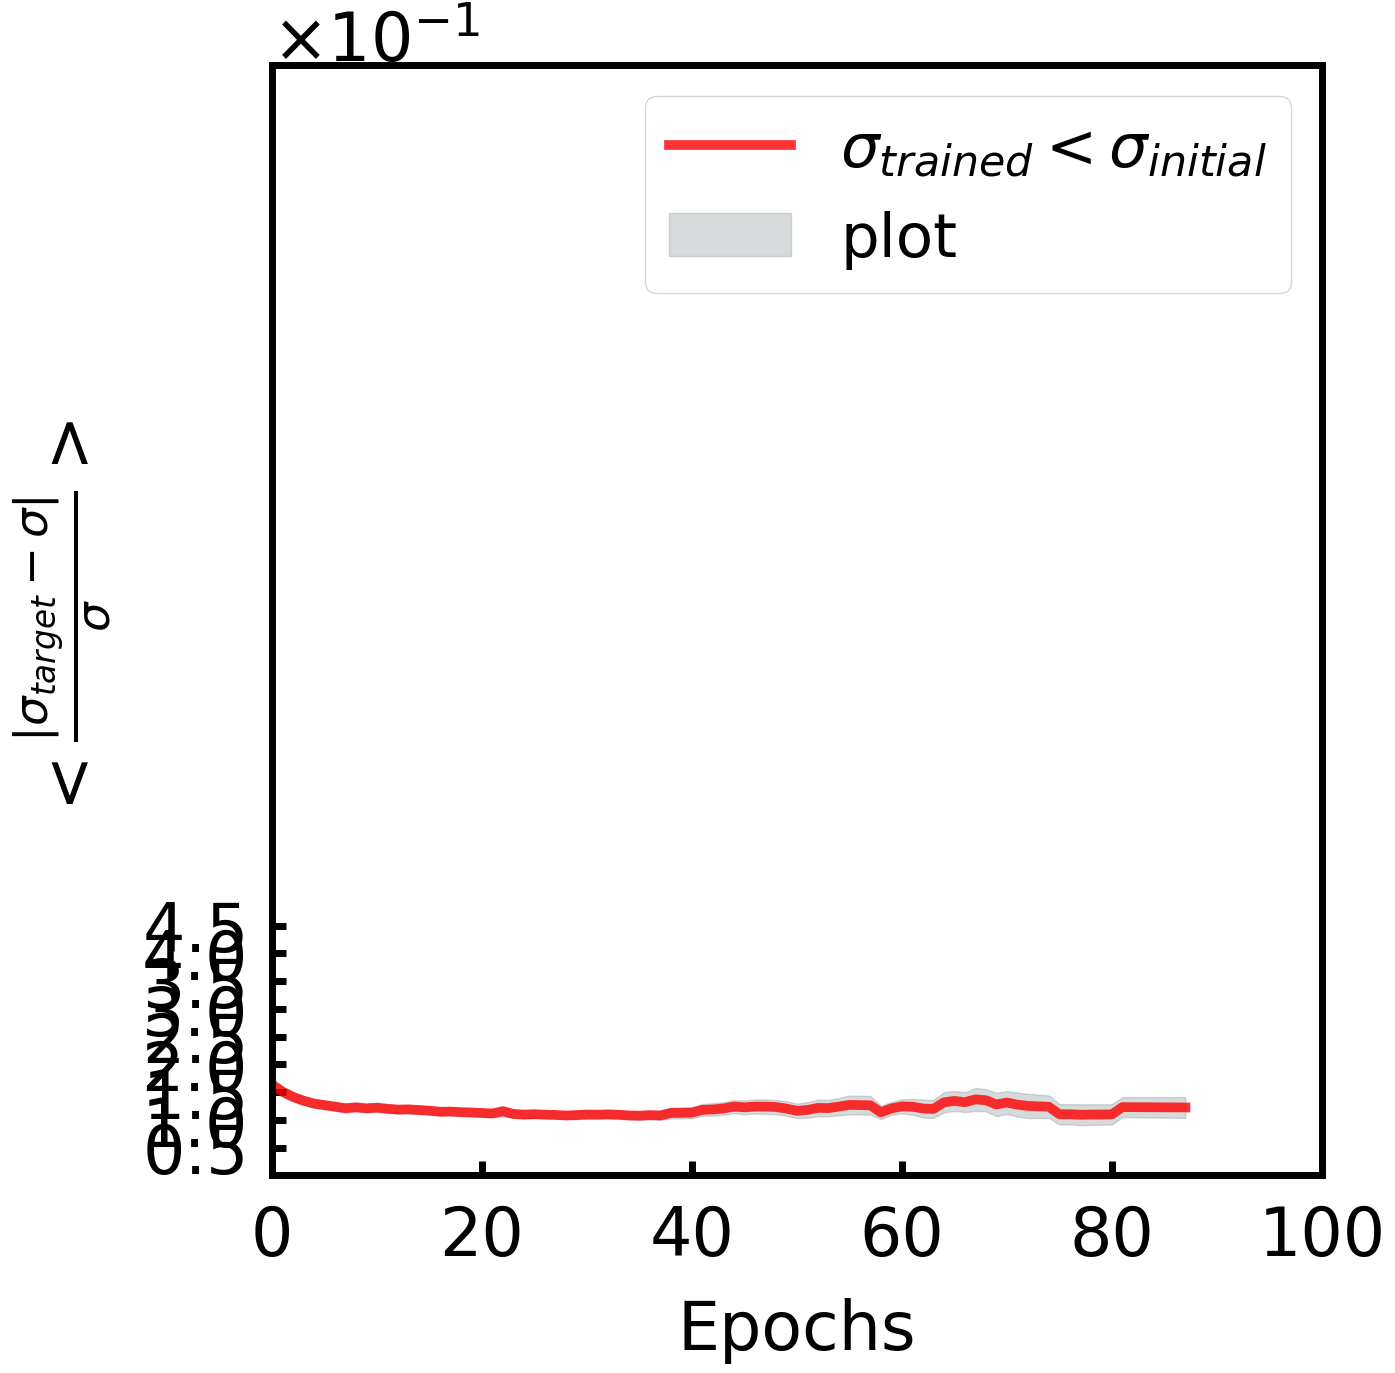

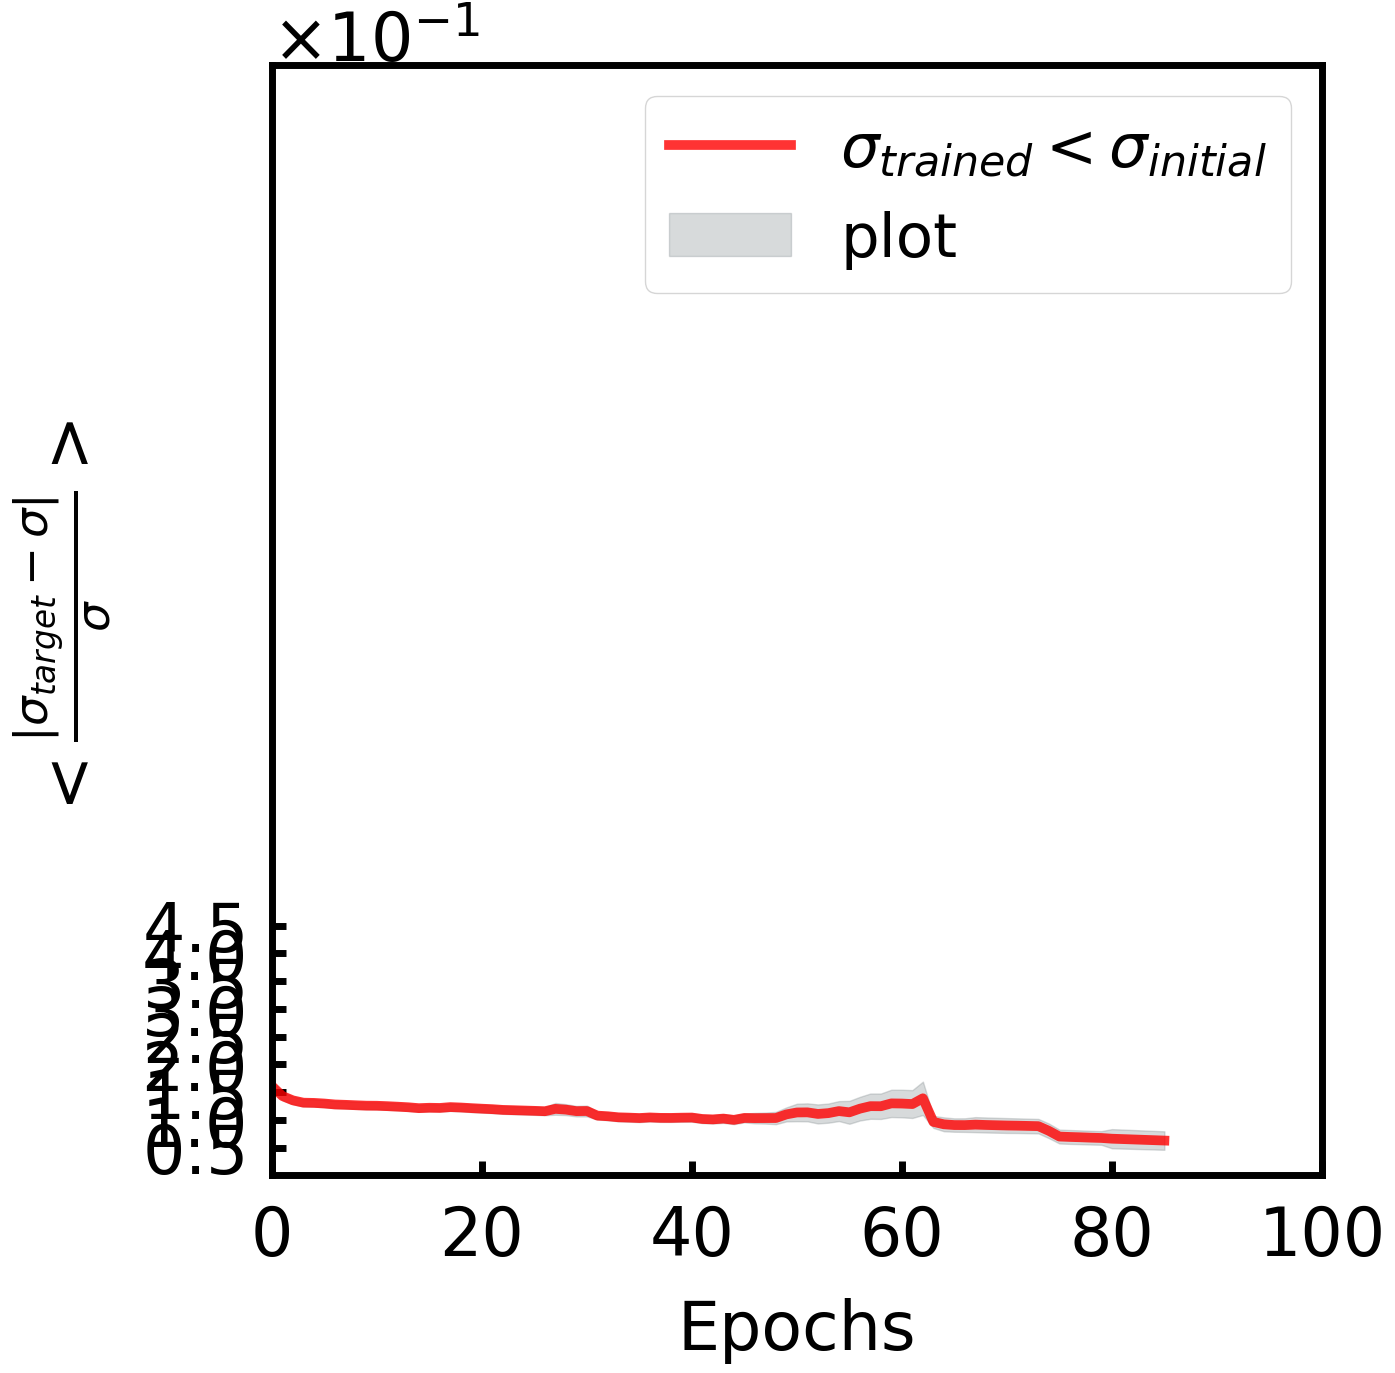

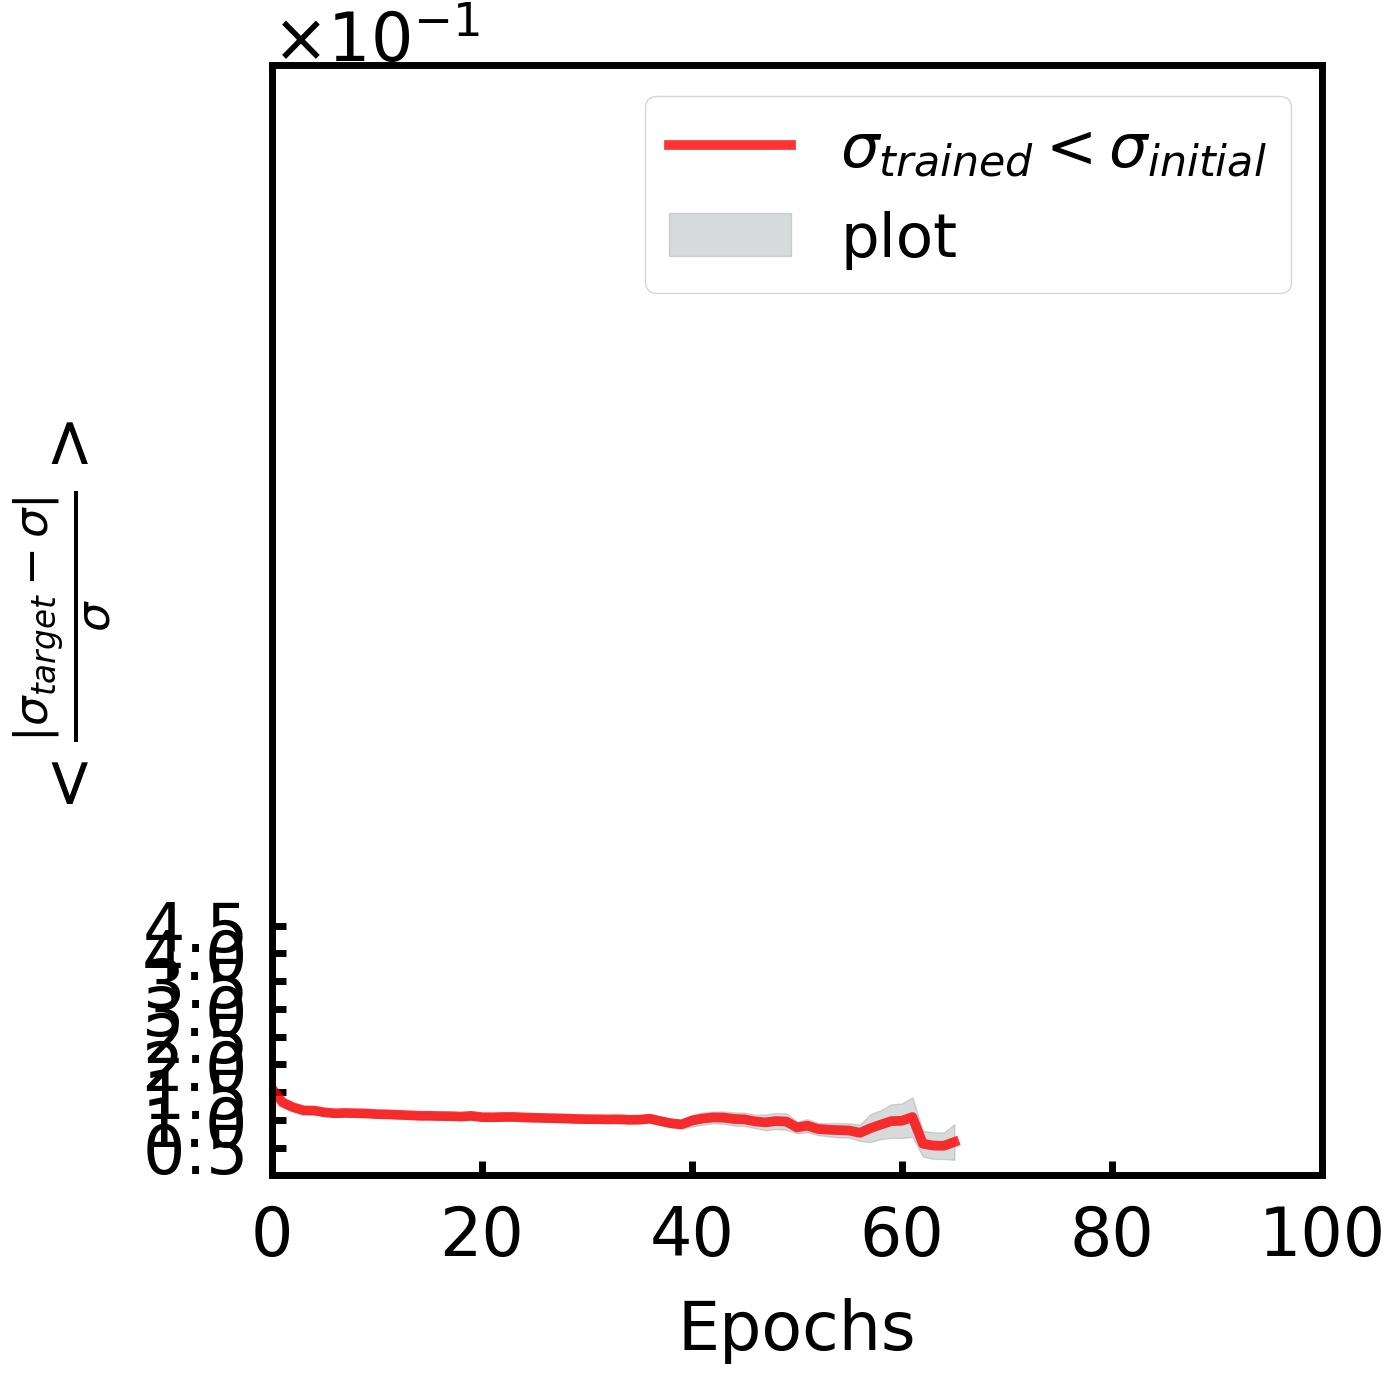

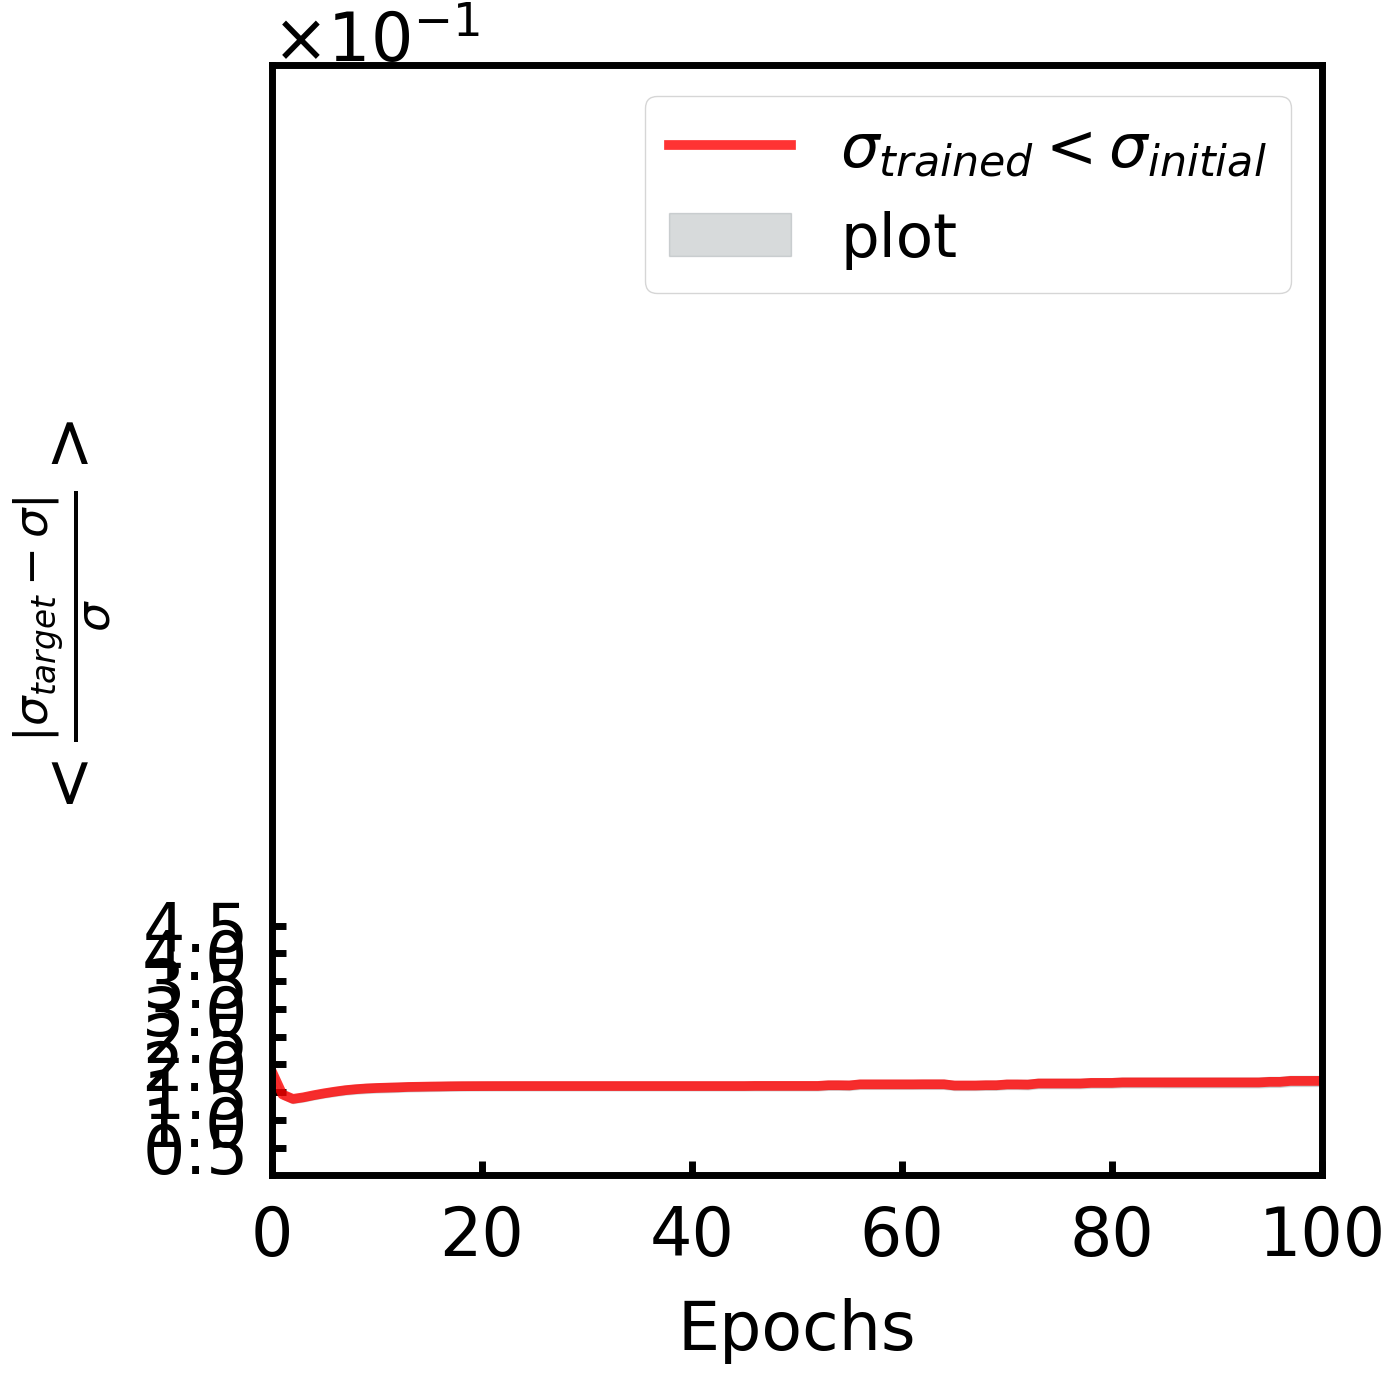

In [ ]:
from toolbox import manuscriptPlots
from scripts.data_processing import download
import numpy as np
import pandas as pd
import os

s0_vals = [4.8,4.9,5.0,5.1,5.2,5.3]
d_list = ["1_cell_increase/", "1_cell_decrease/", "2_cells/","4_cells/"]
# colormap = {"":"red", "final":"blue"}
# labelmap = {"init": "Initial", "final": "Final"}
# filename = "graphs/stress_tensor_manuscript/kappa_{:.2f}.png".format(p)
for d in d_list:
    for s0 in s0_vals:
        experiment = "{}7_{:.1f}/".format(d,s0)
        download(experiment)
        input_file = "{}error.csv".format(experiment)
        plotter = manuscriptPlots.plot()
        plotter.set_ylim(1e-5,2)
        plotter.set_xlim(0,100)
        # plotter.set_title(" p = {:.2f}".format(p))
        plotter.set_xlabel("Epochs")
        plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
        # plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

        plotter.set_xticks([20*i for i in range(100)])
        plotter.set_yticks([0.05*i for i in range(1,10)])
        plotter.set_yScaled()

        plotter.initialize_figure()
        # plotter.set_yLog()
        df = pd.read_csv(input_file)
        costs = df["mean"].to_numpy()
        err = df["sem"].to_numpy()
        if not len(costs):
            continue
        epochs = [i for i in range(len(costs))]
        plotter.plot_xy(epochs,costs,label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
        # plotter.ax.set_yscale("log")
        plotter.plot_errorfill(epochs,costs,err)
        # plotter.ax.set_yscale("log")
        # plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
        plotter.save_fig("/Users/shabeebameen/Projects/tvm-fire/{}error.jpg".format(experiment))

# df = pd.read_csv("../tvm-fire/sp_5_cell_increase/costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}>\sigma_{initial}$", color= "blue",alpha = 0.8)

# df = pd.read_csv("../tvm-fire/mp_2_cells/patternA_costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "Pattern A", color= "red",alpha = 0.6)

# df = pd.read_csv("../tvm-fire/mp_2_cells/patternB_costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "Pattern B", color= "blue",alpha = 0.6)

# df = pd.read_csv("../tvm-fire/mp_2_cells/distances.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "_Pattern A", color= "black",alpha = 0.6)

# plotter.save_fig("/Users/shabeebameen/Projects/tvm-fire/mp_2_cells_distances.jpg")


In [1]:
import os


def write_scripts(output_dir):
    lines_sub = []
    lines_sub.append("executable = /home/mameen/examples/singularity_wrapper.sh\n")
    lines_sub.append("arguments  = /home/mameen/examples/ubuntu18_povray_paula.img /home/mameen/{}minimize_config.sh\n".format(output_dir))
    lines_sub.append("transfer_input_files = /home/mameen/scripts/minimize_config.py, /home/mameen/setup.py, /home/mameen/toolbox\n")
    lines_sub.append("should_transfer_files = YES\n")
    lines_sub.append("output     = output.txt\n")
    lines_sub.append("error      = error.txt\n")
    lines_sub.append("log        = log.txt\n")
    lines_sub.append("getenv     = True\n")
    lines_sub.append("request_cpus = 1\n")
    lines_sub.append("request_memory = 100 MB\n")
    lines_sub.append('Requirements = TARGET.vm_name == "its-u20-nfs-20210413" && regexp("CRUSH", TARGET.name)\n')
    lines_sub.append("queue")
    with open("{}minimize_config.sub".format(output_dir), "w") as f:
        for line in lines_sub:
            f.write(line)

    lines_sh = []
    lines_sh.append("#!/bin/bash\n")
    lines_sh.append("source /home/mameen/.bashrc\n")
    lines_sh.append("pip install --user -e .\n")
    lines_sh.append("python /home/mameen/scripts/minimize_config.py /home/mameen/{}\n".format(output_dir))
    with open("{}minimize_config.sh".format(output_dir), "w") as f:
        for line in lines_sh:
            f.write(line)

    



for s0 in [4.8,4.9,5.0,5.1,5.2,5.3]:
    for i in range(100):
        os.system("cp conf_{:.1f} init_homogeneous/7_{:.1f}/{:03d}/conf".format(s0,s0,i))
        output_dir = "init_homogeneous/7_{:.1f}/{:03d}/".format(s0,i)
        write_scripts(output_dir)


cp: conf_4.8: No such file or directory


FileNotFoundError: [Errno 2] No such file or directory: 'init_homogeneous/7_4.8/000/minimize_config.sub'

In [ ]:
code = """
import os
for s0 in [4.8,4.9,5.0,5.1,5.2,5.3]:
    os.makedirs("init/7_{:.1f}/".format(s0), exist_ok=True)
    success_dirs = []
    for i in range(100):
        output_dir = "init_homogeneous/7_{:.1f}/{:03d}/".format(s0,i)
        if not os.path.isfile("{}minimized.txt".format(output_dir)):
            continue
        success_dirs.append(output_dir)
    for k, dir in enumerate(success_dirs):
        os.system("cp -r {} init/7_{:.1f}/{:03d}/".format(dir,s0,k))

"""
exec(code)

In [ ]:
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox.training import Training

dir = "test_5.4/"
sample = PeriodicTissue.from_config(dir,"sample.topo")

min_instance = Training.periodic_tissue(sample)
min_instance.set_cpp_executable_dir("/Users/shabeebameen/Projects/tvm-fire/build/")
min_instance.edit_conf(log = 1000, final_time = 10000,s0 = 5.4)
min_instance.minimize_config()

s0 edited: 5.4
final_time edited: 10000
log edited: 1000
Initialization start ...

cellParameters.input not present or could not be processed.
Proceeding minimization with homogeneous cell properties.
Initial F_rms: 1.92417

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.002       343.000     0           0           60.237448   828.695013  888.932461  1.924172    
1000.00     392.076     343.000     1760        2016        0.049549    0.085279    0.134828    0.011350    
2000.00     399.357     343.000     506         511         0.040061    0.068419    0.108480    0.011786    
3000.00     394.083     343.000     401         397         0.039165    0.054805    0.093971    0.010966    
4000.00     384.602     343.000     361         364         0.036469    0.056927    0.093396    0.012145    
5000.00     375.942     343.000     310         306         0.03189

In [2]:
import pandas as pd
from toolbox.pattern_trainer import resume_run

dir = "sp_5_cell_increase/run_13/"
resume_run(dir)

   cellID    Stress
0     329  0.280785
1     134  0.273648
2      82  0.177339
3     240  0.226956
4     100  0.303447
{329: 0.2807852728044566, 134: 0.273647633037523, 82: 0.1773390879016674, 240: 0.2269555758121479, 100: 0.3034470845471293}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

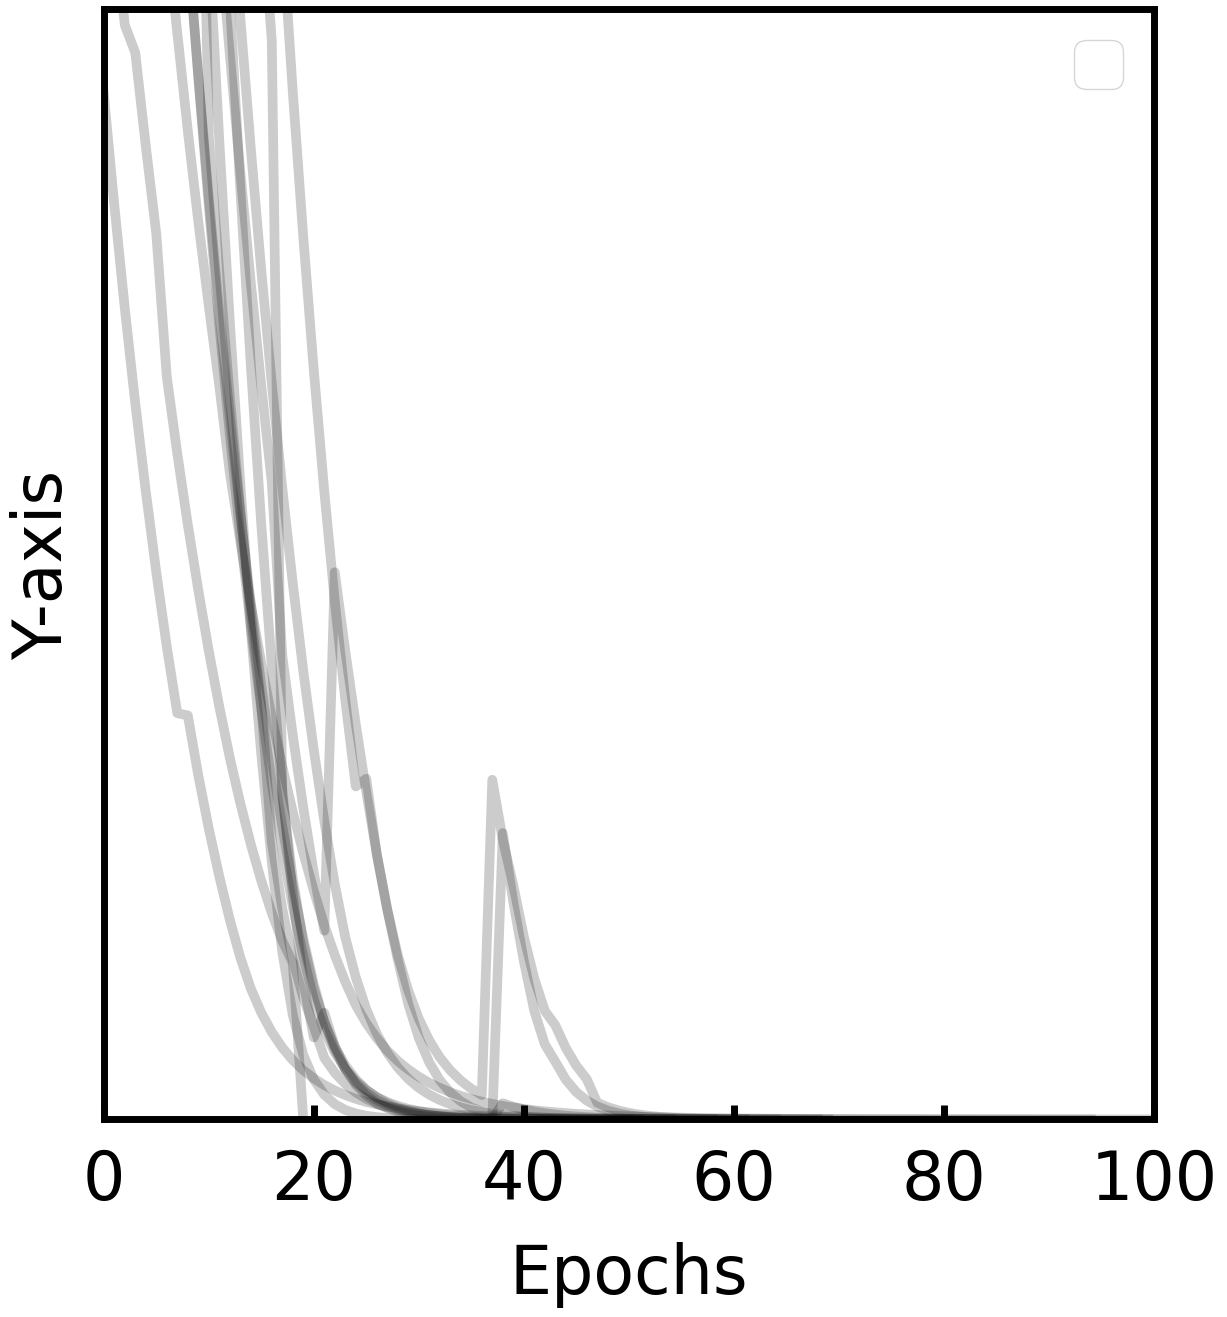

In [2]:
from toolbox import manuscriptPlots
import numpy as np
import pandas as pd
import os
# colormap = {"":"red", "final":"blue"}
# labelmap = {"init": "Initial", "final": "Final"}
# filename = "graphs/stress_tensor_manuscript/kappa_{:.2f}.png".format(p)

plotter = manuscriptPlots.plot()
plotter.set_ylim(0,1e-2)
plotter.set_xlim(0,100)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel("Epochs")
plotter.set_xticks([20*i for i in range(100)])
plotter.set_yticks([10*i for i in range(1,10)])
plotter.set_yScaled()
plotter.initialize_figure()

for i in range(20):
    input_file = "sp_1_cell_increase/run_{}/costs.txt".format(i)
    if not os.path.isfile(input_file):
        continue
    costs = np.loadtxt(input_file)
    if costs[-1]>1e-6:
        continue
    # print(costs)
    plotter.plot_xy([i for i in range(len(costs))],costs, color= "black", label = "_None",alpha = 0.2)
    # plotter.histogram_from_dataframe(df["Final_s0"],color="green", label = r"$\sigma_{trained}>\sigma_{initial}$", bins=20,alpha = 0.6)
    # plotter.ax.plot((5,5),(0,10), color = "black", alpha = 0.2, linestyle = "--", label = "Initial")
    # plotter.ax.legend()
    plotter.save_fig("/Users/shabeebameen/Projects/tvm-fire/sp_1_cell_costs.jpg")

In [7]:
import os
experiments_list = ["sp_1_cell_increase",
                    "sp_1_cell_decrease",
                    # "sp_2_cell_increase",
                    # "sp_2_cell_decrease",
                    "sp_5_cell_increase",
                    "sp_5_cell_decrease"]
for experiment in experiments_list:
    os.makedirs(experiment, exist_ok=True)
    # os.system("scp mameen@smatter-login.syr.edu:/home/mameen/{}/histogram_data.csv {}".format(experiment,experiment))
    os.system("scp mameen@smatter-login.syr.edu:/home/mameen/{}/costs.csv {}/".format(experiment,experiment))

    # for i in range(20):
    #     dir = experiment+"/"+"run_{}/".format(i)
    #     os.makedirs(dir, exist_ok= True)
    #     os.system("scp mameen@smatter-login.syr.edu:/home/mameen/{}/costs.csv {}/".format(experiment,experiment))


In [ ]:
import os
for i in range(100):
    for file in ["error.txt","output.txt","log.txt"]:
        os.system("rm init_homogeneous/7_5.2/{:03d}/{}".format(i,file))
    os.system("cp conf init_homogeneous/7_5.2/{:03d}/".format(i))
    os.system("cd init_homogeneous/7_5.2/{:03d}/ && chmod +x minimize_config.sh && condor_submit minimize_config.sub".format(i))

0.3805342954609416

In [6]:
(.381-0.21744816883482376)/.217

0.7536950744938997

In [ ]:
import pandas as pd
import numpy as np
import glob


dir = "two_cell_training/"
initial_stress = pd.read_csv("{}initial_stress.csv".format(dir))
means = []
final_stress_file = glob.glob("{}*.stresses.csv".format(dir))[-1]
for final_stress_file in sorted(glob.glob("{}*.stresses.csv".format(dir))):
    final_stress = pd.read_csv(final_stress_file)
    targets = final_stress["Target"].to_numpy()
    means.append(np.mean(abs((final_stress["Current"].to_numpy() - targets))/final_stress["Target"].to_numpy()))
   

   cellID    Stress
0     110  0.213505
1      91  0.310052
   CellID  Target   Current
0     110   0.235  0.234242
1      91   0.341  0.340898
0.001761960228373355
[-0.09146754 -0.09075644]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


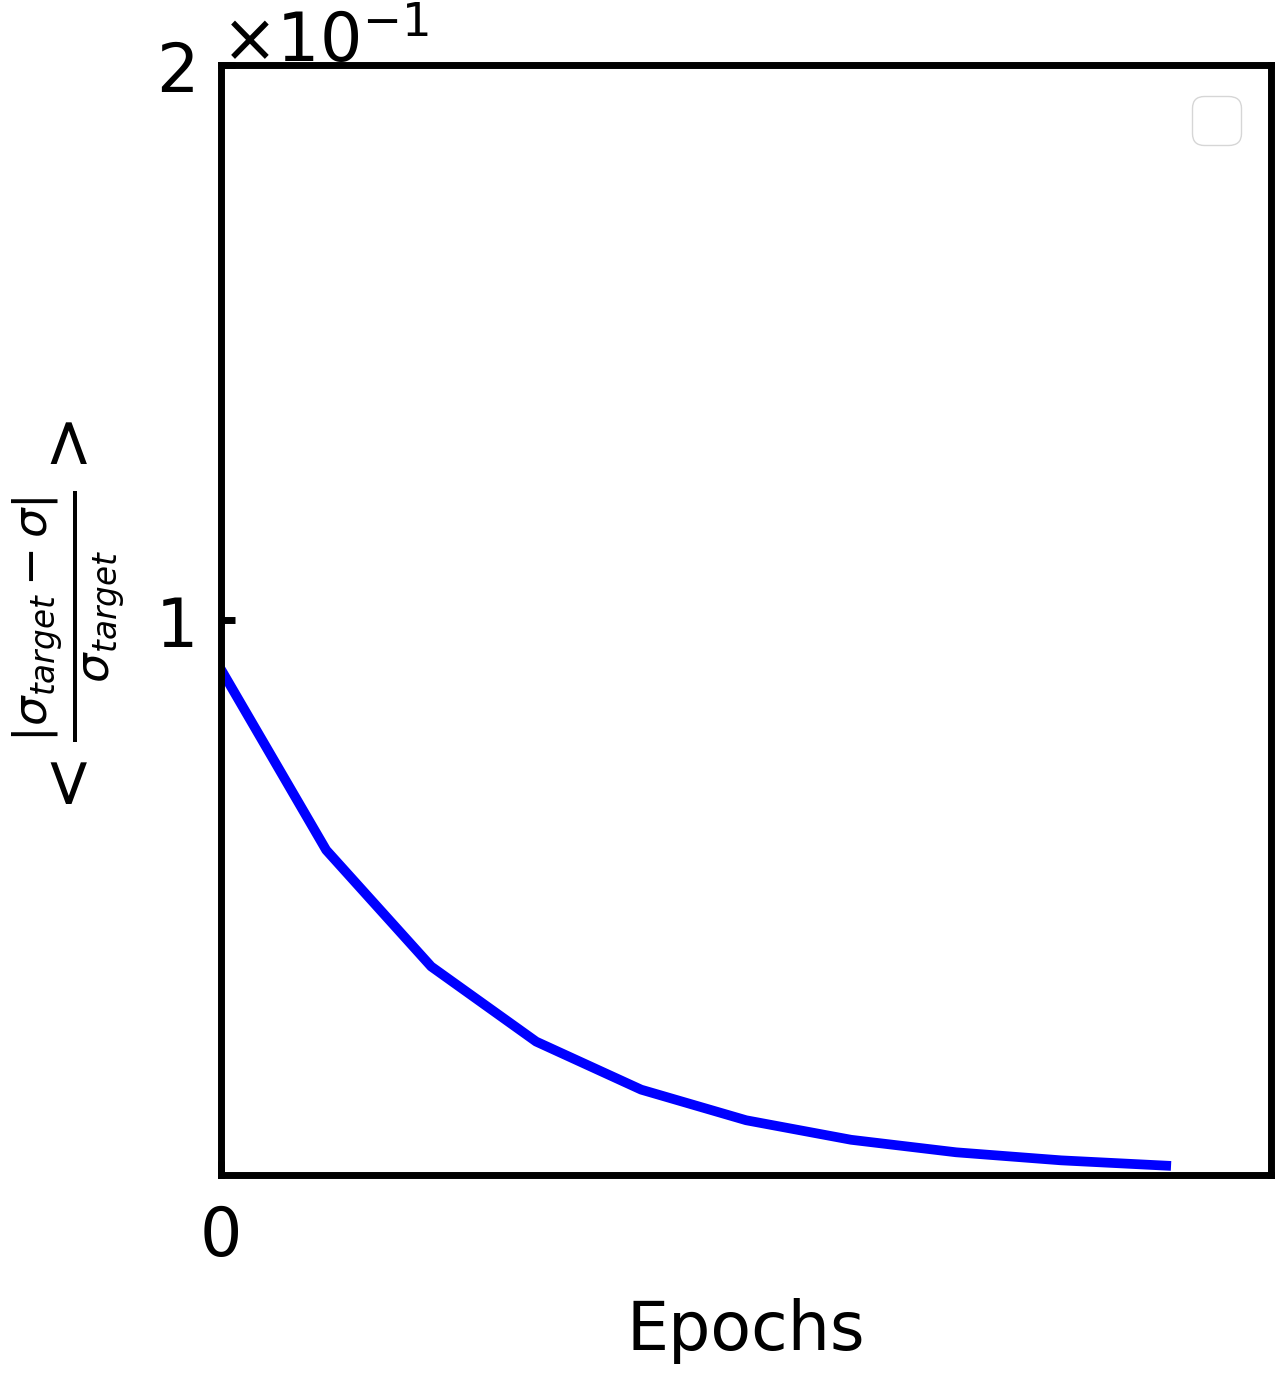

In [28]:
from toolbox import manuscriptPlots
import glob
def training_plot(dir):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,0.2)
    plotter.set_xlim(0,np.ceil(len(np.loadtxt("{}costs.txt".format(dir)))/10)*10)
    plotter.set_xticks([50*i for i in range(1000)])
    plotter.set_yticks([.1*i for i in range(1,100)])
    plotter.set_xlabel("Epochs")
    plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma_{target}}>$")
    plotter.set_yScaled()
    plotter.initialize_figure()

    initial_stress = pd.read_csv("{}initial_stress.csv".format(dir))
    targets = pd.read_csv("{}0000.stresses.csv".format(dir))["Target"].to_numpy()

    means = [np.mean(abs((initial_stress["Stress"].to_numpy() - targets))/targets)]

    final_stress_file = glob.glob("{}*.stresses.csv".format(dir))[-1]
    for final_stress_file in sorted(glob.glob("{}*.stresses.csv".format(dir))):
        final_stress = pd.read_csv(final_stress_file)
        targets = final_stress["Target"].to_numpy()
        means.append(np.mean(abs((final_stress["Current"].to_numpy() - targets))/targets))
        iters = np.arange(len(means))
    plotter.plot_xy(iters, means, color = "blue", label = "_final")
    plotter.save_fig("training.jpg".format(dir))

training_plot("two_cell_training/")

In [ ]:
import os
dir = "samples/"
run = "7_0"
os.system("mkdir -p {}".format(dir+run))
os.system("cp init/7_0/conf {}".format(dir+run))
os.system("cd {} && python /Users/shabeebameen/Projects/tvm-fire/scripts/tvm/main.py conf".format(dir+run))

/Users/shabeebameen/.asdf/installs/python/3.10.14/bin/python: can't open file '/Users/shabeebameen/Projects/tvm-fire/samples/7_0/Users/shabeebameen/Projects/tvm-fire/scripts/tvm/main.py': [Errno 2] No such file or directory


512

In [42]:
from toolbox.periodic import PeriodicTissue
from toolbox.patterns import Patterns
import os
dir = "init/10_0/"
file = "minimized.txt"
# cpp_executable_dir = "tvm/build/"
ids = []
tissue = PeriodicTissue.from_config(dir,file)
for cellID,cell in tissue.cells_.items():
    if cell.center_ is None:
        continue
    if cell.crossBoundary_:
        continue
    if cell.center_[2]>3.7 and cell.center_[2]<4.5:
        ids.append(cellID)
tissue.write_cell_collection_vtk(cells_array=ids, filename="layer.vtk")

In [15]:
import glob
import pandas as pd
import numpy as np
dir = sorted(glob.glob("patternA/*.bulk.txt"))[-1]

# remove the part before the last slash in dir
file = dir.split("/")[-1]
print(dir)
dir = "patternA/"
df = pd.read_csv("{}initial_stress.csv".format(dir))
print(df)
cellID_to_stress = {int(i): float(stress) for i, stress in zip(df["cellID"].to_numpy(), df["Stress"].to_numpy())}
print(cellID_to_stress)
print(np.loadtxt("{}costs.txt".format(dir)))

patternA/0014.bulk.txt
   cellID    Stress
0     142  0.277201
{142: 0.2772011738735123}
[1.57e-04 9.56e-05 6.59e-05 4.53e-05 3.12e-05 2.16e-05 1.49e-05 1.04e-05
 7.20e-06 5.00e-06 3.48e-06 2.43e-06 1.68e-06 1.17e-06 8.21e-07]


In [ ]:
## create cross section of a periodic tissue
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob

dir = "7_bidisperse_5_4.9_0.5_increase/"
# dir = "7_mono_0.5_decrease/"
df = pd.read_csv("{}stresses.csv".format(dir))
print(df["CellID"])
training_cell = df["CellID"].to_numpy()[0]
ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
final_iter = max(ids)
file = "{}.bulk.txt".format(final_iter)
sample = PeriodicTissue.from_config(dir,file)
min = FIREminimization.periodic_tissue(sample)
min.load_cell_parameters("cellParameters.{}.input".format(final_iter))

for cellID, cell in sample.cells_.items():
    cell.vtk_scalar_ = cell.s0_
    cell.vtk_scalar_ = stress.calculate_max_shear_stress(sample, cellID)
normal = np.array([1,0,0])
center = sample.cells_[training_cell].center_
print(sample.cells_[training_cell].s0_)
makeSampleCrossSection(sample=min._config, center = center, normal = normal, filename = "cross_section.vtk")
single_cell = sample.extract_cell(training_cell)
makeSampleCrossSection(sample=single_cell, center=center, normal = normal, filename="single_cell_cross_section.vtk")



0    331
Name: CellID, dtype: int64
5.0


In [10]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob
dir = "mp_2_cells/run_0/PatternB/"
df = pd.read_csv("{}initial_stress.csv".format(dir))
# print(df["cellID"])
# ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
# ids = sorted(ids)
# final_iter = 33
# for iter in range(final_iter+1):
file = "0000.bulk.txt"
sample = PeriodicTissue.from_config(dir,file)
sample.write_cell_collection_vtk(df["cellID"].to_numpy(),"target_cells_isolated.vtk",use_scalar=False)
# sample.write_cell_collection_vtk([64],"target_cells_isolated.vtk",use_scalar=False)


# min = FIREminimization.periodic_tissue(sample)

# min.load_cell_parameters("cellParameters.{}.input".format(iter))
# for i, row in df.iterrows():
#     cellID = row["CellID"]
#     target_stress = row["Target"]
#     cell = sample.cells_[cellID]
#     # shear = stress.calculate_max_shear_stress(sample, cellID)
#     # cell.max_shear_stress_ = shear
#     # vtk_scalar = abs(cell.max_shear_stress_ - target_stress)/ target_stress
#     for polygonID in cell.polygons_:
#         polygon = sample.polygons_[polygonID]
#         # polygon.vtk_scalar_ = vtk_scalar
# for cellID in df["CellID"].to_numpy():
    # sample.write_cell_collection_vtk(df["CellID"].to_numpy(),"{}.target_cells.vtk".format(iter),use_scalar=True)
    # sample.write_cell_collection_vtk([cellID],"{}single.{}.vtk".format(dir,cellID),use_scalar=False)

